# 09 — Độ ổn định (K-Fold) và hiệu chuẩn xác suất: OMI

**Dự án ACS-ECG-AI (Vinmec)** · nối tiếp [`06_omi_model_comparison.ipynb`](06_omi_model_comparison.ipynb)

Notebook `06` xếp hạng mười một kiến trúc trên **một** lần chia train/val, **một** seed, và tự ghi
nhận dao động **±0,015 AUROC** khi chạy lại. Bốn model đầu bảng — `PlainCNN` (AUPRC 0,5219),
`TCN1D` (0,5160), `ResNet1D` (0,5134), `WBF-ensemble` (0,5134) — nằm gọn trong khoảng nhiễu đó, nên
**thứ hạng giữa chúng chưa có căn cứ**.

Notebook này trả lời ba câu hỏi:

1. **`PlainCNN` có thật sự tốt hơn không**, hay chênh lệch chỉ là nhiễu của một lần chạy? → 5-fold
   theo bệnh nhân, cùng bộ fold cho mọi model, kiểm định ghép cặp (mục 13–16).
2. **Ở cùng một điểm vận hành thì model nào hơn?** `Sensitivity` ở bảng cũ đo tại ngưỡng Youden's J
   riêng của từng model nên không so được với nhau. Mục 17 ép tất cả về cùng Specificity = 0,85 —
   cùng tinh thần với mục 15 của notebook `06` (ép về Sensitivity 0,697 để so với paper).
3. **Xác suất đầu ra đọc được như xác suất thật không, và ngưỡng vận hành sai số bao nhiêu?**
   → hiệu chuẩn cross-fit (mục 18) và bootstrap CI theo bệnh nhân cho ngưỡng ba mức (mục 19).

OMI là bài toán khó hơn STEMI (AUPRC ~0,52 so với ~0,67) và cũng là bài **có giá trị lâm sàng cao
nhất**: 37% ca OMI nằm trong nhóm NSTEMI, tức tiêu chí ST chênh lên bỏ sót chúng. Ngưỡng rule-out ở
mục 19 vì thế phải kèm khoảng tin cậy, không thể chỉ một con số điểm.

**Phạm vi:** huấn luyện lại các model nằm trong vùng nhiễu **±0,015 AUROC** so với model đơn tốt
nhất của `06` (`PlainCNN`, AUROC 0,9201) — **8 ứng viên**: `PlainCNN`, `ConvNeXtV2_1D`, `TCN1D`,
`SEResNet1D`, `ResNet1D`, `InceptionTime1D`, `AiTiAMI`, `XResNet1D`. `CNN+BiLSTM` (0,8945),
`PaperBaselineCNN` (0,8896, cũng là tái hiện) và `Transformer1D` (0,8493) nằm ngoài ngưỡng, chỉ được
**chấm lại bằng checkpoint cũ** ở mục 17(a). `WBF-ensemble`/`Average-ensemble` không thể "huấn luyện
lại" vì là tổ hợp trọng số của cả mười một model gốc; mục 14b dựng lại đúng công thức đó trên các
ứng viên đã qua K-Fold (tên biến `WBF-3`/`Average-3` trong code là tên lịch sử từ bản đầu 3 ứng viên,
giữ nguyên để không phá vỡ mục 22 — không phản ánh đúng số 8 hiện tại).

⚠️ **Danh sách `CANDIDATES` vừa được mở rộng từ 3 lên 8 model nhưng notebook CHƯA được chạy lại** —
mọi output từ mục 14 trở đi (bảng kết quả, kiểm định, hiệu chuẩn, kể cả mục 22 phân nhóm NSTEMI) vẫn
là kết quả của lần chạy 3 ứng viên cũ, giữ lại làm tư liệu tham khảo. Cần "Run All" lại trên Colab để
có kết quả cho 8 ứng viên — mục 22 khi đó cũng sẽ tự động dùng OOF của 8 ứng viên mới vì nó đọc lại
từ `ALL_NAMES`/`OOF_P`, không hardcode danh sách model.

**Tập test ẩn 10% không được chạm tới ở bất kỳ bước nào.**

## 1. Cài thư viện

Chỉ cài `wfdb` nếu môi trường chưa có. Trên Colab cần cài lại mỗi phiên (~10 giây).

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

Đang cài wfdb ...
wfdb 4.3.1


## 2. Cấu hình

Notebook chạy được trên **Google Colab** và **máy cá nhân**, tự nhận diện môi trường.
Chỉ cần sửa đúng một chỗ:

- **Colab** → `DRIVE_PROJECT` (tên thư mục trên Drive chứa `datasets.zip`)
- **Máy cá nhân** → `LOCAL_DATA_ROOT`

Ngoài ra đổi `RUN_MODE` khi muốn chuyển từ chạy thử sang chạy thật.

**Thư mục `outputs/` chỉ giữ hai thứ:** checkpoint mô hình và cache tín hiệu. Hình và bảng số
đều hiển thị ngay trong notebook nên không ghi ra file nữa.

Trên Colab, cache đặt ở `/content` (nhanh, mất khi hết phiên) và được sao lưu lên Drive để phiên
sau khỏi tiền xử lý lại; checkpoint ghi thẳng lên Drive để không mất khi đứt phiên.

In [2]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"       # "debug" = 200 bản ghi / 3 epoch  |  "full" = toàn bộ / 30 epoch

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"                    # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"                     # cache tín hiệu (sinh lại được)
MODEL_DIR = PERSIST_DIR / "models" / "omi_compare"    # checkpoint (không được mất)
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

# ===================== THAM SỐ =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3       # bandpass Butterworth
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
ECE_BINS = 10
TARGET_LABEL = "OMI"
CLASS_NAME = "OMI"

# Số ca theo paper, tính trên TOÀN BỘ 19.955 bản ghi (Table 3 + mục Data overview).
# OMI = 807 (trong nhóm STEMI) + 467 (trong nhóm NSTEMI) = 1.274.
# train.csv chỉ giữ 90% (10% còn lại là test ẩn), nên số KỲ VỌNG đếm được = paper × 0,9 —
# đối chiếu với con số đã nhân 0,9 chặt hơn hẳn so trực tiếp với con số gốc.
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197, "AMI": 2933, "OMI": 1274}
TRAIN_FRAC = 0.90
SANITY_TOL = 0.12

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)

# ============ K-FOLD + HIỆU CHUẨN (notebook 09) ============
ORIG_MODEL_DIR = MODEL_DIR                 # checkpoint của notebook 06 — CHỈ đọc, để inference lại
MODEL_DIR = PERSIST_DIR / "models" / "omi_kfold"
OOF_DIR = PERSIST_DIR / "oof"

K_FOLDS = 5
N_REPEATS = 1          # 2 -> 10 cặp, Wilcoxon HAI phía mới đủ lực (xem mục 16). Gấp đôi chi phí GPU.
CANDIDATES = ["PlainCNN", "ConvNeXtV2_1D", "TCN1D", "SEResNet1D", "ResNet1D",
              "InceptionTime1D", "AiTiAMI", "XResNet1D"]  # vùng nhiễu ±0,015 AUROC quanh model đơn tốt nhất (06)
SPEC_TARGET = 0.85     # điểm vận hành chung để so matched-threshold
RULE_OUT_NPV = 0.99    # ngưỡng rule-out lâm sàng
N_BOOTSTRAP = 1000
RUN_SWEEP = False      # True = chạy mục 20 (sweep hyperparameter), tốn thêm nhiều giờ GPU

N_FOLDS_RUN = 1 if RUN_MODE == "debug" else K_FOLDS   # debug chỉ chạy fold đầu

print("Ứng viên   :", ", ".join(CANDIDATES))
print("K-Fold     :", f"{K_FOLDS} fold × {N_REPEATS} lần lặp, chạy {N_FOLDS_RUN} fold ở chế độ {RUN_MODE}")
print("Checkpoint :", MODEL_DIR)

Môi trường : Google Colab
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : OMI
Ứng viên   : PlainCNN, ConvNeXtV2_1D, TCN1D, SEResNet1D, ResNet1D, InceptionTime1D, AiTiAMI, XResNet1D
K-Fold     : 5 fold × 1 lần lặp, chạy 5 fold ở chế độ full
Checkpoint : /content/drive/MyDrive/ACS-ECG-AI/outputs/models/omi_kfold


### 2b. Chuẩn bị dữ liệu

Trên máy cá nhân cell này chỉ tạo thư mục. Trên Colab nó mount Drive (sẽ hiện popup xin quyền —
đây là thao tác thủ công duy nhất), copy `datasets.zip` về `/content` rồi giải nén.

Phải đi vòng qua zip vì bộ dữ liệu có **59.867 file**, mà Drive tính mỗi lần mở file là một lệnh
gọi mạng — đọc trực tiếp từ Drive sẽ chậm hơn hàng chục lần.

In [3]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(
            f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}"
        )

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

Mounted at /content/drive
Copy zip 1.33 GB từ Drive ...
  15s
Giải nén ...
  27s
DATA_ROOT: /content/_extract/datasets | tồn tại: True


## 3. Seed & GPU

In [4]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 × 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, và kết quả không tái lập chính xác 100%.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA A100-SXM4-80GB


## 4. Dữ liệu và nhãn

Nhãn chỉ có trong `train.csv` (phần 90% chính thức). `test.csv` là tập test ẩn, không có cột nhãn
và **không bao giờ được đọc** trong notebook này.

Nhãn đích lấy thẳng cột `OMI`. Theo định nghĩa của paper, `OMI = 1` nghĩa là **báo cáo chụp mạch ghi
nhận tắc cấp tính với TIMI flow 0–1 ở mạch thủ phạm trước khi can thiệp PCI** — tức nhãn dựa trên
giải phẫu mạch thật, không phải suy ra từ hình dạng ECG.

Sanity check đối chiếu với số ca của paper **đã nhân 0,9** (phần mà `train.csv` nắm giữ), thay vì so
thẳng với con số tính trên toàn bộ 19.955 bản ghi.

In [5]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check: so với (số của paper × 0,9) vì train.csv chỉ giữ 90% ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'kỳ vọng':>10}{'lệch':>9}")
ok_all = True
for _name, _full in PAPER_COUNTS.items():
    got = int(df_raw[_name].sum())
    exp = _full * TRAIN_FRAC
    delta = (got - exp) / exp
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{_name:<8}{got:>11,}{exp:>10,.0f}{delta:>8.1%}   "
          f"{'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print(f"\n!! CẢNH BÁO: có nhãn lệch quá ±{SANITY_TOL:.0%} so với kỳ vọng — kiểm tra nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["OMI"].astype(int)
print("\nNhãn = cột OMI (tắc cấp hoàn toàn TIMI 0-1 theo báo cáo chụp mạch, trước PCI)")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được   kỳ vọng     lệch
STEMI         1,442     1,362    5.9%   OK
NSTEMI        1,235     1,147    7.7%   OK
UA            6,213     5,577   11.4%   OK
AMI           2,679     2,640    1.5%   OK
OMI           1,151     1,147    0.4%   OK

Nhãn = cột OMI (tắc cấp hoàn toàn TIMI 0-1 theo báo cáo chụp mạch, trước PCI)

Nhãn OMI: 1,151 dương (6.41%) / 16,809 âm


## 5. Lấy mẫu khi chạy thử

Ở `RUN_MODE="debug"` lấy 200 bản ghi **stratified** theo nhãn, để tập mẫu không rơi vào toàn 0
hoặc toàn 1 (khi đó mọi metric sẽ vô định).

In [6]:
from sklearn.model_selection import train_test_split

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

Dùng 17,960 bản ghi | 1,151 dương (6.41%)


## 7. Tiền xử lý và cache

Với mỗi bản ghi: đọc WFDB → NaN→0 → cắt/đệm về đúng 5000 mẫu → bandpass Butterworth 0,5–40 Hz
(`filtfilt`, zero-phase). **Chuẩn hoá z-score làm sau**, ở bước 9, với mean/std tính riêng trên tập
train để không rò rỉ thống kê của val sang train.

Lọc lại toàn bộ ở mỗi epoch là nút thắt cổ chai, nên tín hiệu đã lọc được cache **một lần** vào
memmap `float16` (~2,2 GB cho 17.960 bản ghi). Cache nối tiếp được nếu bị ngắt giữa chừng, và trên
Colab được sao lưu lên Drive.

> **Dùng chung cache với notebook 01/03.** Ở `RUN_MODE="full"`, danh sách bản ghi ở đây giống hệt
> hai notebook kia (cùng toàn bộ `train.csv`, chỉ khác cột nhãn), nên tên file cache — vốn băm từ
> danh sách `record_stem` — trùng nhau và bước tiền xử lý được bỏ qua hoàn toàn. Ở `debug` thì mẫu
> stratified theo nhãn OMI khác mẫu theo nhãn STEMI, nên cache riêng, đúng như mong muốn.

> **Hai bản ghi lỗi trong dữ liệu gốc.** `03228` và `14262` có file `.dat` chỉ chứa 3.500/5.000 mẫu,
> khiến `wfdb.rdrecord()` báo lỗi. Hàm dưới bắt lỗi đó, đọc phần thực có rồi để bước zero-pad bù nốt.

In [7]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    # Colab: thử lấy lại cache của phiên trước từ Drive
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Lấy cache từ Drive (2.01 GB) ...
  40s — bỏ qua tiền xử lý
Cache đã đầy đủ: sig_full_n17960_c20c6dba.npy
Cache: (17960, 12, 5000) float16


## 9. Chia train/val theo bệnh nhân

Bắt buộc chia theo `Patient_id`: một bệnh nhân có thể có nhiều ECG trong 7 ngày trước DSA, chia theo
bản ghi sẽ khiến cùng một người xuất hiện ở cả train lẫn val.

Stratify ở **cấp bệnh nhân** (lấy `max` nhãn của người đó) — cần thiết vì có bệnh nhân mang nhãn
không đồng nhất giữa các bản ghi của chính mình.

Ngay sau khi chia, mean/std cho z-score được tính **chỉ trên các bản ghi thuộc train**.

In [8]:
pat = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
strat = pat[TARGET_LABEL] if pat[TARGET_LABEL].value_counts().min() >= 2 else None
pat_tr, pat_va = train_test_split(pat, test_size=VAL_SIZE, stratify=strat, random_state=SEED)

train_idx = df.index[df[COL_PATIENT].isin(set(pat_tr[COL_PATIENT]))].to_numpy()
val_idx = df.index[df[COL_PATIENT].isin(set(pat_va[COL_PATIENT]))].to_numpy()
y = df[TARGET_LABEL].values.astype(np.float32)

assert not (set(pat_tr[COL_PATIENT]) & set(pat_va[COL_PATIENT])), "RÒ RỈ: bệnh nhân ở cả 2 tập"
print("Giao nhau patient_id: RỖNG -> OK\n")

display(pd.DataFrame({
    "tập": ["train", "val"],
    "bệnh nhân": [len(pat_tr), len(pat_va)],
    "bản ghi": [len(train_idx), len(val_idx)],
    "dương": [int(y[train_idx].sum()), int(y[val_idx].sum())],
    "tỷ lệ dương": [f"{y[train_idx].mean():.2%}", f"{y[val_idx].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


LEAD_MEAN, LEAD_STD = norm_stats(train_idx)
print(f"\nz-score fit trên {len(train_idx):,} bản ghi TRAIN")

Giao nhau patient_id: RỖNG -> OK



,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,train,14465,15256,977,6.40%
1,val,2553,2704,174,6.43%



z-score fit trên 15,256 bản ghi TRAIN


## 10. Dataset & DataLoader

In [9]:
from torch.utils.data import DataLoader, Dataset


class ECGDataset(Dataset):
    """Khác notebook 06 đúng một chỗ: nhận mean/std làm tham số.

    z-score phải fit lại trên tập train CỦA TỪNG FOLD, không dùng chung một bộ
    thống kê toàn cục được — nếu không thì thống kê của fold này rò rỉ sang fold kia.
    Mặc định vẫn là LEAD_MEAN/LEAD_STD của lần chia 85/15 gốc, để mục 17
    (nạp lại checkpoint cũ) chuẩn hoá y hệt lúc các model đó được huấn luyện.
    """

    def __init__(self, indices, labels, mean=None, std=None):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = (LEAD_MEAN if mean is None else mean).reshape(-1, 1)
        self.std = (LEAD_STD if std is None else std).reshape(-1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}


def make_loaders(tr_idx, va_idx, mean=None, std=None):
    ds_tr = ECGDataset(tr_idx, y[tr_idx], mean, std)
    ds_va = ECGDataset(va_idx, y[va_idx], mean, std)
    tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
    va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
    return tr, va


# Loader của lần chia 85/15 GỐC — chỉ dùng ở mục 17 để chấm lại checkpoint của notebook 06
train_loader, val_loader = make_loaders(train_idx, val_idx)

xb, yb = next(iter(val_loader))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(train_loader)} batch train, {len(val_loader)} batch val (split 85/15 gốc)")

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 239 batch train, 43 batch val (split 85/15 gốc)


## 11. Hàm tính metric

`compute_metrics` an toàn với tập nhỏ: khi chỉ có một lớp hoặc mẫu số bằng 0, trả `nan` thay vì
ném lỗi hay trả 0 gây hiểu nhầm.

`per_class_report` cho bảng tách riêng **lớp âm tính (0)** và **lớp dương tính (1)** — mỗi lớp có
Precision/Recall/F1/Support riêng, kèm hai dòng trung bình macro và weighted.

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def per_class_report(y_true, y_prob, threshold):
    """Bảng metric TÁCH RIÊNG cho lớp 0 và lớp 1, kiểu classification_report của sklearn."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(y_prob).ravel() >= threshold).astype(int)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    rows = [
        {"Class": f"Negative (0) — không {CLASS_NAME}", "Precision": p[0], "Recall": r[0],
         "F1": f[0], "Support": int(s[0])},
        {"Class": f"Positive (1) — {CLASS_NAME}", "Precision": p[1], "Recall": r[1],
         "F1": f[1], "Support": int(s[1])},
    ]
    w = s / s.sum()
    rows.append({"Class": "macro avg", "Precision": p.mean(), "Recall": r.mean(),
                 "F1": f.mean(), "Support": int(s.sum())})
    rows.append({"Class": "weighted avg", "Precision": float(p @ w), "Recall": float(r @ w),
                 "F1": float(f @ w), "Support": int(s.sum())})
    return pd.DataFrame(rows).set_index("Class")


def style_df(df, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df.columns if c not in pct_cols and df[c].dtype.kind in "iu"})
    try:
        return df.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df.columns])
    except Exception:
        return df.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}


## 12. Mười một kiến trúc

Tất cả nhận input `(batch, 12, 5000)` và trả về **một logit** cho mỗi mẫu, nên có thể thay thế nhau
trong đúng một vòng lặp huấn luyện.

Cả mười một đều hạ chiều thời gian khá mạnh (5000 → vài chục/vài trăm) trước khi gộp, vì tín hiệu 10
giây ở 500 Hz là quá dài để giữ nguyên độ phân giải qua nhiều tầng.

> ⚠️ **`AiTiAMI` là tái hiện theo mô tả kiến trúc, không phải model/trọng số gốc.** Lee *et al.*
> (*Eur Heart J* 2025, ehaf004 — nghiên cứu ROMIAE) chỉ mô tả AiTiAMI v1.00.00 của Medical AI Co.
> là "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo
> thô, đầu ra điểm xác suất AMI 0-100. Không có chi tiết số khối, độ sâu, hay trọng số công khai —
> class `AiTiAMI` dưới đây là một ResNet1D sâu/rộng hơn `ResNet1D` sẵn có, kernel hẹp hơn (5 thay
> vì 7), head kết hợp avg+max-pool.

> ⚠️ **`PaperBaselineCNN` bám sát sơ đồ nhưng không phải bản sao chạy được của paper.** Fig. 9 của
> Du *et al.* cho đủ số kênh vào/ra, kernel (71), stride (1) và padding (35) của cả 10 lớp conv, nên
> phần **kết nối và số kênh được tái hiện chính xác** — mỗi conv trong một khối nhận `concat` toàn bộ
> đầu ra trước đó của khối, kiểu DenseNet. Ba chỗ notebook này **cố ý làm khác**:
>
> 1. **Input `raw 12×5000` thay vì `median beat 12×500`.** Paper dùng file `.med`; ở đây mọi model
>    ăn chung tín hiệu thô để so sánh giữa 11 kiến trúc là công bằng. Đây là khác biệt lớn nhất và
>    là lý do chính khiến không thể kỳ vọng tái lập con số AUROC 0,900.
> 2. **Thêm BatchNorm sau mỗi conv.** Sơ đồ gốc chỉ vẽ conv → relu. Không có BN, mạng 10 lớp conv
>    kernel 71 rất dễ phân kỳ ở LR 1e-3 dùng chung cho cả bộ.
> 3. **Head là `AdaptiveAvgPool1d(1)` → `Linear(16, 1)` một logit** thay vì `fc` 2 lớp + CrossEntropy
>    như paper, để khớp với `BCEWithLogitsLoss(pos_weight=...)` mà cả 11 model ở đây dùng chung.

In [11]:
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    """Mốc sàn: Conv-BN-ReLU-MaxPool xếp chồng, không có gì đặc biệt."""

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    """Skip connection giúp gradient đi xuyên qua mạng sâu."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    """Nhiều độ dài kernel song song -> bắt được cả sóng nhanh lẫn biến thiên chậm."""

    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        # hạ tần số ngay từ đầu, nếu không 5000 mẫu × nhiều kênh sẽ quá nặng
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32          # số kênh của tensor dùng làm residual, KHÁC c_in của khối hiện tại
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            # residual mỗi 3 khối, kèm hạ chiều thời gian
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    """CNN rút đặc trưng cục bộ, BiLSTM mô hình hoá quan hệ theo thời gian giữa các nhịp."""

    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)                       # 5000 -> ~78
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)                          # (B, T, C)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)            # gộp trung bình theo thời gian

# ---------------------------------------------------------------- 5. SEResNet1D
class SEBlock1D(nn.Module):
    """Squeeze-excitation: học trọng số quan trọng theo từng kênh (feature map)."""

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w


class SEResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.se = SEBlock1D(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.se(self.bn2(self.conv2(out)))
        return self.relu(out + idt)


class SEResNet1D(nn.Module):
    """ResNet1D + squeeze-excitation sau mỗi khối."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(SEResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 6. Transformer1D
class Transformer1D(nn.Module):
    """Cắt tín hiệu thành patch theo thời gian, học vị trí, qua self-attention."""

    def __init__(self, patch_len=250, d_model=128, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        assert SIGNAL_LEN % patch_len == 0
        n_patches = SIGNAL_LEN // patch_len
        self.patch_len = patch_len
        self.proj = nn.Linear(NUM_LEADS * patch_len, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 4,
                                           dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x):
        b = x.shape[0]
        patches = x.unfold(-1, self.patch_len, self.patch_len)          # (B, 12, n_patches, patch_len)
        patches = patches.permute(0, 2, 1, 3).reshape(b, patches.shape[2], -1)
        tok = self.proj(patches)
        tok = torch.cat([self.cls_token.expand(b, -1, -1), tok], dim=1) + self.pos_embed
        out = self.norm(self.encoder(tok))
        return self.head(out[:, 0]).squeeze(-1)


# ---------------------------------------------------------------- 7. TCN1D
class TCNBlock1D(nn.Module):
    """Conv1D giãn nở (dilated), residual — receptive field rộng mà giữ độ phân giải thời gian."""

    def __init__(self, c_in, c_out, k=7, dilation=1, dropout=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(c_in, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1, bias=False)

    def forward(self, x):
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.short(x))


class TCN1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 128, 256, 256), dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for i, c_out in enumerate(channels):
            blocks.append(TCNBlock1D(c_in, c_out, dilation=2 ** i, dropout=dropout))
            if i % 2 == 1:                       # hạ chiều thời gian định kỳ, không hạ mỗi lớp
                blocks.append(nn.MaxPool1d(2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 8. XResNet1D
class XResBlock1D(nn.Module):
    """Nhánh tắt kiểu xResNet: AvgPool + 1x1 conv thay vì strided conv khi downsample."""

    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.act = nn.SiLU(inplace=True)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.AvgPool1d(stride, ceil_mode=True), nn.Conv1d(c_in, c_out, 1, bias=False),
                nn.BatchNorm1d(c_out))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.act(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class XResNet1D(nn.Module):
    """Stem sâu (3 conv nhỏ xếp chồng) thay vì 1 conv to + SiLU — biến thể tối ưu hoá của ResNet1D."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 5, 2, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(XResBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.SiLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 9. ConvNeXtV2_1D
class GRN1D(nn.Module):
    """Global Response Normalization (ConvNeXt V2) — chuẩn hoá theo norm toàn cục của từng kênh."""

    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, channels))
        self.beta = nn.Parameter(torch.zeros(1, 1, channels))

    def forward(self, x):                          # x: (B, L, C)
        gx = torch.norm(x, p=2, dim=1, keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block1D(nn.Module):
    def __init__(self, channels, expand=4, dropout=0.1):
        super().__init__()
        self.dwconv = nn.Conv1d(channels, channels, 7, padding=3, groups=channels, bias=False)
        self.norm = nn.LayerNorm(channels)
        self.pw1 = nn.Linear(channels, channels * expand)
        self.act = nn.GELU()
        self.grn = GRN1D(channels * expand)
        self.pw2 = nn.Linear(channels * expand, channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):                           # x: (B, C, L)
        idt = x
        x = self.dwconv(x).transpose(1, 2)           # (B, L, C)
        x = self.norm(x)
        x = self.pw2(self.grn(self.act(self.pw1(x))))
        x = self.drop(x).transpose(1, 2)
        return x + idt


class ConvNeXtV2Downsample1D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.norm = nn.BatchNorm1d(c_in)
        self.conv = nn.Conv1d(c_in, c_out, 2, stride=2, bias=False)

    def forward(self, x):
        return self.conv(self.norm(x))


class ConvNeXtV2_1D(nn.Module):
    """Khối depthwise-conv + LayerNorm + MLP mở rộng + GRN — bản 1D của ConvNeXt V2."""

    def __init__(self, channels=(32, 64, 128, 256), depths=(1, 1, 2, 1), dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, channels[0], 4, stride=4, bias=False),
                                  nn.BatchNorm1d(channels[0]))
        stages, c_in = [], channels[0]
        for stage_i, (c_out, depth) in enumerate(zip(channels, depths)):
            if stage_i > 0:
                stages.append(ConvNeXtV2Downsample1D(c_in, c_out))
            stages += [ConvNeXtV2Block1D(c_out, dropout=dropout) for _ in range(depth)]
            c_in = c_out
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.LayerNorm(c_in), nn.Dropout(dropout), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.stages(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 10. AiTiAMI (tái hiện)
class AiTiAMIBlock1D(nn.Module):
    """Residual block chuẩn, kernel hẹp hơn ResNet1D (5 thay vì 7) để bắt chi tiết QRS/ST mịn hơn."""

    def __init__(self, c_in, c_out, k=5, stride=2, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class AiTiAMI(nn.Module):
    """Tái hiện theo MÔ TẢ KIẾN TRÚC trong Lee et al., Eur Heart J 2025 (ehaf004, ROMIAE):
    "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo.
    KHÔNG PHẢI model/trọng số gốc của Medical AI Co., Ltd — bài báo không công bố kiến trúc chi
    tiết (sản phẩm thương mại). Sâu hơn (5 stage) và rộng hơn ResNet1D, head avg+max-pool nối tiếp.
    """

    def __init__(self, channels=(48, 96, 192, 256, 320), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 48, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(48), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 48
        for i, c_out in enumerate(channels):
            blocks.append(AiTiAMIBlock1D(c_in, c_out, stride=2 if i < 4 else 1))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in * 2, 128), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        feat = self.blocks(self.stem(x))
        pooled = torch.cat([self.avgpool(feat), self.maxpool(feat)], dim=1)
        return self.head(pooled).squeeze(-1)


# ---------------------------------------------------------------- 11. PaperBaselineCNN
class PaperBaselineCNN(nn.Module):
    """Tái hiện kiến trúc baseline của CHÍNH paper bộ dữ liệu này (Du et al., Sci Data 13:1009,
    2026 — Fig. 9). Mười lớp conv kernel 71, stride 1, padding 35, chia ba khối; trong mỗi khối
    mỗi conv nhận concat toàn bộ đầu ra trước đó (kiểu DenseNet), maxpool giữa các khối.

    Số kênh lấy đúng từ sơ đồ:
        khối 1: conv1 12->32 | pool | conv2 32->32 | conv3 64->32 | conv4 96->32 | pool
        khối 2: conv5 32->24 | conv6 56->24 | conv7 80->24 | pool
        khối 3: conv8 24->16 | conv9 40->16 | conv10 56->16
    Các số vào (64, 96, 56, 80, 40, 56) khớp chính xác với phép concat, đây là bằng chứng đọc
    đúng sơ đồ chứ không phải đoán.

    KHÁC bản gốc ở ba điểm cố ý (xem markdown mục 12): input raw 12x5000 thay vì median beat
    12x500, có thêm BatchNorm, và head một logit thay vì fc 2 lớp + CrossEntropy.
    """

    def __init__(self, dropout=0.3):
        super().__init__()
        K, P = 71, 35

        def cbr(c_in, c_out):
            return nn.Sequential(nn.Conv1d(c_in, c_out, K, 1, P, bias=False),
                                 nn.BatchNorm1d(c_out), nn.ReLU(inplace=True))

        self.conv1 = cbr(NUM_LEADS, 32)
        self.conv2 = cbr(32, 32)
        self.conv3 = cbr(64, 32)
        self.conv4 = cbr(96, 32)
        self.conv5 = cbr(32, 24)
        self.conv6 = cbr(56, 24)
        self.conv7 = cbr(80, 24)
        self.conv8 = cbr(24, 16)
        self.conv9 = cbr(40, 16)
        self.conv10 = cbr(56, 16)
        self.pool = nn.MaxPool1d(4)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(dropout), nn.Linear(16, 1))

    def forward(self, x):
        x = self.pool(self.conv1(x))                          # (B, 32, 1250)
        c2 = self.conv2(x)                                     # 32 -> 32
        c3 = self.conv3(torch.cat([x, c2], 1))                 # 64 -> 32
        c4 = self.conv4(torch.cat([x, c2, c3], 1))             # 96 -> 32
        x = self.pool(c4)                                      # (B, 32, 312)

        c5 = self.conv5(x)                                     # 32 -> 24
        c6 = self.conv6(torch.cat([x, c5], 1))                 # 56 -> 24
        c7 = self.conv7(torch.cat([x, c5, c6], 1))             # 80 -> 24
        x = self.pool(c7)                                      # (B, 24, 78)

        c8 = self.conv8(x)                                     # 24 -> 16
        c9 = self.conv9(torch.cat([x, c8], 1))                 # 40 -> 16
        c10 = self.conv10(torch.cat([x, c8, c9], 1))           # 56 -> 16
        return self.head(c10).squeeze(-1)


MODELS = {
    "PlainCNN": PlainCNN,
    "ResNet1D": ResNet1D,
    "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM,
    "SEResNet1D": SEResNet1D,
    "Transformer1D": Transformer1D,
    "TCN1D": TCN1D,
    "XResNet1D": XResNet1D,
    "ConvNeXtV2_1D": ConvNeXtV2_1D,
    "AiTiAMI": AiTiAMI,
    "PaperBaselineCNN": PaperBaselineCNN,
}


rows = []
for name, cls in MODELS.items():
    m = cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
    rows.append({"Mô hình": name, "Tham số": sum(p.numel() for p in m.parameters()),
                 "Output": str(tuple(out.shape))})
    del m
torch.cuda.empty_cache() if GPU_AVAILABLE else None
display(pd.DataFrame(rows).set_index("Mô hình"))

,Tham số,Output
Mô hình,,
PlainCNN,304961,"(2,)"
ResNet1D,986753,"(2,)"
InceptionTime1D,483137,"(2,)"
CNN+BiLSTM,339265,"(2,)"
SEResNet1D,998273,"(2,)"
Transformer1D,1180417,"(2,)"
TCN1D,2116929,"(2,)"
XResNet1D,993281,"(2,)"
ConvNeXtV2_1D,929601,"(2,)"


## 13. Chia K-Fold theo bệnh nhân

Thay lần chia 85/15 duy nhất bằng `StratifiedKFold` chạy trên **bảng cấp bệnh nhân** (nhãn của một
bệnh nhân = `max` nhãn các bản ghi của họ, đúng như mục 9). Chia ở cấp bệnh nhân rồi mới map ngược
về bản ghi là cách duy nhất đảm bảo cứng rằng không bệnh nhân nào xuất hiện ở hai fold — chia trực
tiếp theo bản ghi sẽ rò rỉ, vì 855 bệnh nhân có nhiều hơn một ECG.

**Cùng một bộ fold dùng cho cả ba ứng viên** — đó là điều kiện để so sánh ở mục 16 là *paired*
(so từng fold một), chứ không phải so hai giá trị trung bình rời rạc.

In [12]:
from sklearn.model_selection import StratifiedKFold

pat_tbl = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
POS_RATE_ALL = float(y.mean())

FOLDS = {}          # (rep, k) -> (train_idx, val_idx)
for rep in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED + rep)
    for k, (_, va_pos) in enumerate(skf.split(pat_tbl, pat_tbl[TARGET_LABEL])):
        va_pats = set(pat_tbl.iloc[va_pos][COL_PATIENT])
        in_va = df[COL_PATIENT].isin(va_pats).to_numpy()
        FOLDS[(rep, k)] = (df.index[~in_va].to_numpy(), df.index[in_va].to_numpy())

# --- AC1: không bệnh nhân nào ở hai fold, và mọi bản ghi được validate đúng một lần ---
for rep in range(N_REPEATS):
    seen = set()
    for k in range(K_FOLDS):
        pats_k = set(df.loc[FOLDS[(rep, k)][1], COL_PATIENT])
        assert not (seen & pats_k), f"RÒ RỈ: bệnh nhân nằm ở hai fold (rep {rep}, fold {k})"
        seen |= pats_k
        assert not (set(df.loc[FOLDS[(rep, k)][0], COL_PATIENT]) & pats_k), \
            f"RÒ RỈ: bệnh nhân vừa ở train vừa ở val (rep {rep}, fold {k})"
    cover = np.concatenate([FOLDS[(rep, k)][1] for k in range(K_FOLDS)])
    assert len(cover) == len(df) and len(set(cover)) == len(df), "Các fold không phủ đúng một lần"
print(f"Giao nhau bệnh nhân giữa các fold: RỖNG -> OK ({N_REPEATS} lần lặp)")

# --- AC1: tỷ lệ dương mỗi fold lệch không quá 2 điểm % so với toàn tập ---
rows, worst = [], 0.0
for (rep, k), (tr, va) in FOLDS.items():
    rate = float(y[va].mean())
    worst = max(worst, abs(rate - POS_RATE_ALL))
    rows.append({"lặp": rep, "fold": k, "bệnh nhân val": df.loc[va, COL_PATIENT].nunique(),
                 "bản ghi train": len(tr), "bản ghi val": len(va),
                 "dương val": int(y[va].sum()), "tỷ lệ dương val": rate,
                 "lệch (điểm %)": (rate - POS_RATE_ALL) * 100})
fold_df = pd.DataFrame(rows)
display(fold_df.style.format({"tỷ lệ dương val": "{:.2%}", "lệch (điểm %)": "{:+.2f}"}))
assert worst <= 0.02, f"Fold lệch tỷ lệ dương tới {worst:.2%} > 2 điểm %"
print(f"Tỷ lệ dương toàn tập {POS_RATE_ALL:.2%} | lệch lớn nhất {worst * 100:.2f} điểm % -> OK")

Giao nhau bệnh nhân giữa các fold: RỖNG -> OK (1 lần lặp)


,lặp,fold,bệnh nhân val,bản ghi train,bản ghi val,dương val,tỷ lệ dương val,lệch (điểm %)
0,0,0,3404,14360,3600,229,6.36%,-0.05
1,0,1,3404,14379,3581,230,6.42%,+0.01
2,0,2,3404,14356,3604,230,6.38%,-0.03
3,0,3,3403,14373,3587,229,6.38%,-0.02
4,0,4,3403,14372,3588,233,6.49%,+0.09


Tỷ lệ dương toàn tập 6.41% | lệch lớn nhất 0.09 điểm % -> OK


## 14. Huấn luyện các ứng viên trên từng fold

Pipeline giữ **nguyên xi** notebook 06: `BCEWithLogitsLoss(pos_weight)`, AdamW, `ReduceLROnPlateau`
theo val AUPRC, early stopping, gradient clipping, AMP. Chỉ hai thứ tính lại theo từng fold vì bắt
buộc phải thế: `pos_weight` (phụ thuộc số ca dương trong train của fold đó) và `LEAD_MEAN/LEAD_STD`
(z-score fit trên train của fold đó).

Mỗi (model, fold) có checkpoint riêng kèm *fingerprint*. Run All lại notebook: cặp nào đã có
checkpoint khớp thì bỏ qua train, chỉ chạy cặp còn thiếu.

Dự đoán out-of-fold (OOF) được ghi ra `.npz`. Nếu file này đã đầy đủ, **toàn bộ mục 14 bị bỏ qua** —
các mục phân tích 15–19 chạy lại được trên máy không có GPU.

In [13]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

OOF_DIR.mkdir(parents=True, exist_ok=True)
OOF_NPZ = OOF_DIR / f"oof_{TARGET_LABEL}_{RUN_MODE}_k{K_FOLDS}r{N_REPEATS}.npz"
OOF_JSON = OOF_NPZ.with_suffix(".meta.json")

CV_FP = dict(run_mode=RUN_MODE, target=TARGET_LABEL, k=K_FOLDS, reps=N_REPEATS,
             seed=SEED, epochs=EPOCHS, n=len(df), models=CANDIDATES, n_folds_run=N_FOLDS_RUN)

MODEL_LR_OVERRIDE = {"Transformer1D": 3e-4}    # giữ nguyên từ notebook 06
GRAD_CLIP_NORM = 1.0

NAN = float("nan")
OOF_P = {m: np.full((N_REPEATS, len(df)), NAN) for m in CANDIDATES}
FOLD_ID = np.full((N_REPEATS, len(df)), -1, dtype=int)
RUN_INFO = {}


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    y_out, p_out = np.concatenate(ys), np.concatenate(ps)
    bad = ~np.isfinite(p_out)
    if bad.any():
        print(f"  !! {bad.sum()} xác suất không hữu hạn -> thay bằng 0.5; model đang bất ổn định.")
        p_out = np.where(bad, 0.5, p_out)
    return y_out, p_out


def train_fold(name, cls, rep, k, tr_loader, va_loader, pos_weight, tag):
    """Bản sao train_one() của notebook 06, thêm tham số fold thay vì đọc biến toàn cục."""
    ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_r{rep}f{k}_best.pt"
    fp = dict(CV_FP, model=name, rep=rep, fold=k)
    fp.pop("models"), fp.pop("n_folds_run")

    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"  [{tag}] đã có checkpoint khớp -> bỏ qua train "
                  f"(best AUPRC {ck['best']:.4f} @ ep {ck['best_epoch']})")
            return model, ck["hist"], ck["best_epoch"], ck["seconds"]

    torch.manual_seed(SEED + rep)
    np.random.seed(SEED + rep)
    model = cls().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=MODEL_LR_OVERRIDE.get(name, LR),
                                  weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best, best_epoch, bad, hist = -np.inf, -1, 0, []
    t_all = time.time()
    for epoch in range(EPOCHS):
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)

        va_y, va_p = evaluate(model, va_loader)
        m = compute_metrics(va_y, va_p)
        scheduler.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        hist.append({"epoch": epoch + 1, "train_loss": tot / max(seen, 1),
                     "val_auprc": m["auprc"], "val_auroc": m["auroc"]})

        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, best_epoch, bad = float(m["auprc"]), epoch + 1, 0
            torch.save({"model": model.state_dict(), "fp": fp, "best": best,
                        "best_epoch": best_epoch, "hist": hist,
                        "seconds": round(time.time() - t_all, 1)}, ckpt_path)
        else:
            bad += 1
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  [{tag}] ep {epoch + 1:>3}/{EPOCHS}  loss {tot / max(seen, 1):.4f}  "
                  f"val auprc {m['auprc']:.4f}  auroc {m['auroc']:.4f}")
        if bad >= EARLY_STOP_PATIENCE:
            print(f"  [{tag}] early stop @ epoch {epoch + 1}")
            break

    seconds = round(time.time() - t_all, 1)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    ck["seconds"], ck["hist"] = seconds, hist
    torch.save(ck, ckpt_path)
    model.load_state_dict(ck["model"])
    print(f"  [{tag}] xong {len(hist)} epoch trong {seconds:.0f}s | best AUPRC {best:.4f} @ ep {best_epoch}")
    return model, hist, best_epoch, seconds


def _oof_ready():
    if not (OOF_NPZ.exists() and OOF_JSON.exists()):
        return False
    if json.loads(OOF_JSON.read_text()).get("fp") != CV_FP:
        return False
    z = np.load(OOF_NPZ, allow_pickle=False)
    return all(f"p_{m}" in z for m in CANDIDATES)


if _oof_ready():
    _z = np.load(OOF_NPZ, allow_pickle=False)
    for m in CANDIDATES:
        OOF_P[m] = _z[f"p_{m}"]
    FOLD_ID = _z["fold_id"]
    RUN_INFO = json.loads(OOF_JSON.read_text())["runs"]
    print(f"Đã có OOF đầy đủ: {OOF_NPZ.name} -> bỏ qua toàn bộ phần huấn luyện.")
else:
    for rep in range(N_REPEATS):
        for k in range(N_FOLDS_RUN):
            tr_idx_k, va_idx_k = FOLDS[(rep, k)]
            mean_k, std_k = norm_stats(tr_idx_k)
            tr_loader, va_loader = make_loaders(tr_idx_k, va_idx_k, mean_k, std_k)
            n_pos_k = int(y[tr_idx_k].sum())
            pw = float((len(tr_idx_k) - n_pos_k) / max(n_pos_k, 1))
            FOLD_ID[rep, va_idx_k] = k
            print(f"\n=== lặp {rep} · fold {k} " + "=" * 46 +
                  f"\n    train {len(tr_idx_k):,} ({n_pos_k} dương, pos_weight {pw:.2f}) | "
                  f"val {len(va_idx_k):,} ({int(y[va_idx_k].sum())} dương)")
            for name in CANDIDATES:
                tag = f"{name} r{rep}f{k}"
                model, hist, best_epoch, secs = train_fold(
                    name, MODELS[name], rep, k, tr_loader, va_loader, pw, tag)
                _, p = evaluate(model, va_loader)
                OOF_P[name][rep, va_idx_k] = p
                RUN_INFO[f"{name}|{rep}|{k}"] = {
                    "best_epoch": best_epoch, "seconds": secs, "n_epoch": len(hist),
                    "params": sum(q.numel() for q in model.parameters()),
                    "hist": hist}
                del model
                if GPU_AVAILABLE:
                    torch.cuda.empty_cache()

    np.savez_compressed(OOF_NPZ, y=y, fold_id=FOLD_ID,
                        patient=df[COL_PATIENT].astype(str).to_numpy(),
                        **{f"p_{m}": OOF_P[m] for m in CANDIDATES})
    OOF_JSON.write_text(json.dumps({"fp": CV_FP, "runs": RUN_INFO}, ensure_ascii=False))
    print(f"\nĐã ghi OOF -> {OOF_NPZ}")

VALID = np.isfinite(OOF_P[CANDIDATES[0]][0])     # bản ghi đã có dự đoán OOF (debug: chỉ fold 0)
print(f"OOF phủ {VALID.sum():,}/{len(df):,} bản ghi | {int(y[VALID].sum())} ca dương")


=== lặp 0 · fold 0 ==============================================
    train 14,360 (922 dương, pos_weight 14.57) | val 3,600 (229 dương)
  [PlainCNN r0f0] đã có checkpoint khớp -> bỏ qua train (best AUPRC 0.4718 @ ep 14)
  [ConvNeXtV2_1D r0f0] ep   1/30  loss 1.2508  val auprc 0.2460  auroc 0.8361
  [ConvNeXtV2_1D r0f0] ep  10/30  loss 0.8347  val auprc 0.3828  auroc 0.8884
  [ConvNeXtV2_1D r0f0] ep  20/30  loss 0.7020  val auprc 0.3884  auroc 0.8912
  [ConvNeXtV2_1D r0f0] early stop @ epoch 24
  [ConvNeXtV2_1D r0f0] xong 24 epoch trong 151s | best AUPRC 0.4104 @ ep 14
  [TCN1D r0f0] đã có checkpoint khớp -> bỏ qua train (best AUPRC 0.4636 @ ep 20)
  [SEResNet1D r0f0] ep   1/30  loss 1.0677  val auprc 0.2202  auroc 0.8175
  [SEResNet1D r0f0] ep  10/30  loss 0.7625  val auprc 0.3946  auroc 0.8841
  [SEResNet1D r0f0] early stop @ epoch 18
  [SEResNet1D r0f0] xong 18 epoch trong 117s | best AUPRC 0.4608 @ ep 8
  [ResNet1D r0f0] đã có checkpoint khớp -> bỏ qua train (best AUPRC 0.4689 @ e

### 14b. Ensemble kiểu WBF trên các ứng viên

`WBF-ensemble` ở notebook 06 là tổ hợp trọng số của **cả mười/mười một** model, nên không thể
"huấn luyện lại" nó với chỉ vài model con. Ở đây dựng lại đúng công thức ấy nhưng trên các ứng viên —
trọng số tính **trong nội bộ từng fold** (theo AUROC của fold đó) để không mượn thông tin fold khác.
Đây là một điểm so sánh miễn phí, không phải mục tiêu tuning.

In [14]:
_EPS = 1e-3
ENS_NAMES = ["WBF-3", "Average-3"]
for m in ENS_NAMES:
    OOF_P[m] = np.full((N_REPEATS, len(df)), NAN)

for rep in range(N_REPEATS):
    for k in range(N_FOLDS_RUN):
        m_fold = FOLD_ID[rep] == k
        if not m_fold.any():
            continue
        w_raw = {}
        for name in CANDIDATES:
            a = compute_metrics(y[m_fold], OOF_P[name][rep, m_fold])["auroc"]
            w_raw[name] = max((0.5 if np.isnan(a) else a) - 0.5, _EPS)
        w_sum = sum(w_raw.values())
        OOF_P["WBF-3"][rep, m_fold] = sum(
            w_raw[n] / w_sum * OOF_P[n][rep, m_fold] for n in CANDIDATES)
        OOF_P["Average-3"][rep, m_fold] = sum(
            OOF_P[n][rep, m_fold] for n in CANDIDATES) / len(CANDIDATES)

ALL_NAMES = CANDIDATES + ENS_NAMES
print("Đã dựng ensemble trong từng fold:", ", ".join(ENS_NAMES))

Đã dựng ensemble trong từng fold: WBF-3, Average-3


## 15. Kết quả từng fold và độ ổn định

Ngưỡng của mỗi (model, fold) lấy theo Youden's J **tính riêng trong fold đó** — đúng cách notebook
06 làm, để bảng này so được với bảng cũ. Cột `Sensitivity`/`NPV` ở đây vì thế **không** dùng để
kết luận model nào recall tốt hơn; việc đó dành cho mục 17 (ép về cùng một Specificity).

In [15]:
from sklearn.metrics import roc_curve


def youden_threshold(y_true, y_prob):
    if len(np.unique(y_true.astype(int))) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))


rows = []
for name in ALL_NAMES:
    for rep in range(N_REPEATS):
        for k in range(N_FOLDS_RUN):
            m_fold = FOLD_ID[rep] == k
            if not m_fold.any():
                continue
            yk, pk = y[m_fold], OOF_P[name][rep, m_fold]
            met = compute_metrics(yk, pk, youden_threshold(yk, pk))
            rows.append({"Model": name, "lặp": rep, "fold": k, "AUROC": met["auroc"],
                         "AUPRC": met["auprc"], "Sensitivity": met["sensitivity"],
                         "Specificity": met["specificity"], "F1": met["f1"], "NPV": met["npv"],
                         "Threshold": met["threshold"], "n": met["n"], "n_pos": met["n_pos"]})

FOLD_METRICS = pd.DataFrame(rows)
PCT_CV = ["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1", "NPV", "Threshold"]
print("=" * 78)
print(f"KẾT QUẢ TỪNG FOLD — {CLASS_NAME} | {K_FOLDS} fold × {N_REPEATS} lặp")
print("=" * 78)
display(style_df(FOLD_METRICS.set_index(["Model", "lặp", "fold"]), PCT_CV))

agg = FOLD_METRICS.groupby("Model")[["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1", "NPV"]]
summary_cv = agg.agg(["mean", "std"])
summary_cv.columns = [f"{c}_{s}" for c, s in summary_cv.columns]
summary_cv = summary_cv.sort_values("AUPRC_mean", ascending=False)
print("\nTrung bình ± độ lệch chuẩn qua các fold:")
display(style_df(summary_cv, [c for c in summary_cv.columns if c.endswith("_mean")]))

for name in summary_cv.index:
    print(f"  {name:<12} AUPRC {summary_cv.loc[name, 'AUPRC_mean']:.4f} "
          f"± {summary_cv.loc[name, 'AUPRC_std']:.4f}   "
          f"AUROC {summary_cv.loc[name, 'AUROC_mean']:.4f} "
          f"± {summary_cv.loc[name, 'AUROC_std']:.4f}")

CHAMPION = summary_cv.index[0]
CHALLENGER = summary_cv.index[1]
print(f"\n-> Hạng 1 theo AUPRC trung bình: {CHAMPION} | bám sát nhất: {CHALLENGER}")

# Chi phí huấn luyện
if RUN_INFO:
    cost = pd.DataFrame([{"Model": kk.split("|")[0], "Tham số": v["params"],
                          "Thời gian (s)": v["seconds"], "Số epoch": v["n_epoch"]}
                         for kk, v in RUN_INFO.items()])
    print("\nChi phí huấn luyện (tổng qua các fold):")
    display(cost.groupby("Model").agg({"Tham số": "first", "Thời gian (s)": "sum",
                                       "Số epoch": "mean"}).round(1))

KẾT QUẢ TỪNG FOLD — OMI | 5 fold × 1 lặp



Trung bình ± độ lệch chuẩn qua các fold:


,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Sensitivity_mean,Sensitivity_std,Specificity_mean,Specificity_std,F1_mean,F1_std,NPV_mean,NPV_std
Model,,,,,,,,,,,,
WBF-3,0.9059,0.011037,0.4500,0.054527,0.8531,0.021081,0.8294,0.021189,0.3941,0.023873,0.9880,0.001470
Average-3,0.9059,0.011035,0.4497,0.054492,0.8323,0.016182,0.8496,0.021843,0.4151,0.030022,0.9867,0.001009
InceptionTime1D,0.8865,0.010095,0.4220,0.058824,0.8236,0.019841,0.8113,0.024712,0.3616,0.029193,0.9853,0.001516
PlainCNN,0.8902,0.012850,0.4218,0.044133,0.8227,0.012215,0.8245,0.027329,0.3775,0.032591,0.9855,0.000810
ResNet1D,0.8893,0.014118,0.4174,0.048024,0.8404,0.062080,0.8108,0.046618,0.3700,0.040242,0.9869,0.004330
SEResNet1D,0.8871,0.012817,0.4167,0.042882,0.8252,0.035712,0.8155,0.042961,0.3701,0.042935,0.9856,0.002341
AiTiAMI,0.8887,0.010424,0.4144,0.050392,0.8116,0.028131,0.8256,0.035139,0.3761,0.040048,0.9846,0.002004
TCN1D,0.8787,0.022392,0.4144,0.051830,0.8036,0.037022,0.8261,0.027057,0.3723,0.033254,0.9840,0.002838
XResNet1D,0.8820,0.008978,0.3986,0.040712,0.8202,0.018631,0.8253,0.027318,0.3773,0.027875,0.9853,0.001131


  WBF-3        AUPRC 0.4500 ± 0.0545   AUROC 0.9059 ± 0.0110
  Average-3    AUPRC 0.4497 ± 0.0545   AUROC 0.9059 ± 0.0110
  InceptionTime1D AUPRC 0.4220 ± 0.0588   AUROC 0.8865 ± 0.0101
  PlainCNN     AUPRC 0.4218 ± 0.0441   AUROC 0.8902 ± 0.0129
  ResNet1D     AUPRC 0.4174 ± 0.0480   AUROC 0.8893 ± 0.0141
  SEResNet1D   AUPRC 0.4167 ± 0.0429   AUROC 0.8871 ± 0.0128
  AiTiAMI      AUPRC 0.4144 ± 0.0504   AUROC 0.8887 ± 0.0104
  TCN1D        AUPRC 0.4144 ± 0.0518   AUROC 0.8787 ± 0.0224
  XResNet1D    AUPRC 0.3986 ± 0.0407   AUROC 0.8820 ± 0.0090
  ConvNeXtV2_1D AUPRC 0.3976 ± 0.0383   AUROC 0.8889 ± 0.0134

-> Hạng 1 theo AUPRC trung bình: WBF-3 | bám sát nhất: Average-3

Chi phí huấn luyện (tổng qua các fold):


,Tham số,Thời gian (s),Số epoch
Model,,,
AiTiAMI,2116481,805.9,29.4
ConvNeXtV2_1D,929601,830.6,27.6
InceptionTime1D,483137,824.7,27.2
PlainCNN,304961,629.8,25.8
ResNet1D,986753,674.4,25.8
SEResNet1D,998273,744.6,25.4
TCN1D,2116929,781.7,29.8
XResNet1D,993281,719.5,28.6


## 16. Kiểm định: chênh lệch có thật hay là nhiễu?

**Một cảnh báo phải nói trước.** Yêu cầu ban đầu là "Wilcoxon signed-rank, kết luận p < 0,05". Với
**n = 5 cặp**, p **hai phía** nhỏ nhất mà kiểm định này có thể sinh ra là 2/2⁵ = **0,0625** — nghĩa
là dù model thắng cả 5/5 fold thì p vẫn không bao giờ xuống dưới 0,05. Ngưỡng đó bất khả thi về mặt
toán học ở K = 5, không phải vì model kém.

Vì giả thuyết vốn có hướng ("PlainCNN tốt hơn"), notebook báo cáo **Wilcoxon một phía** (p nhỏ nhất
0,03125 ở n = 5 — *có thể* < 0,05), kèm **paired t-test** và **bootstrap CI 95% của ΔAUPRC**. Cái
cuối mới là bằng chứng chính: nó không bị chặn bởi số fold, và nói thẳng khoảng chênh lệch thật sự
nằm ở đâu. Muốn Wilcoxon hai phía đủ lực thì đặt `N_REPEATS = 2` ở mục 2 (10 cặp, gấp đôi GPU).

In [16]:
from scipy.stats import ttest_rel, wilcoxon

PAT_CODES = pd.factorize(df[COL_PATIENT].astype(str))[0]


def cluster_bootstrap_delta(name_a, name_b, n_boot=N_BOOTSTRAP, seed=SEED):
    """CI của ΔAUPRC, lấy mẫu lại THEO BỆNH NHÂN (một bệnh nhân có thể có nhiều bản ghi)."""
    mask = VALID
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    starts = np.searchsorted(codes_sorted, np.unique(codes_sorted))
    groups = np.split(idx_sorted, starts[1:])
    rng = np.random.default_rng(seed)
    pa, pb = OOF_P[name_a][0], OOF_P[name_b][0]
    out = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        ys = y[sel]
        if len(np.unique(ys.astype(int))) < 2:
            continue
        out.append(average_precision_score(ys, pa[sel]) - average_precision_score(ys, pb[sel]))
    return np.asarray(out)


def compare_two(name_a, name_b):
    piv = FOLD_METRICS.pivot_table(index=["lặp", "fold"], columns="Model", values="AUPRC")
    a, b = piv[name_a].to_numpy(), piv[name_b].to_numpy()
    d = a - b
    n = len(d)
    print("=" * 78)
    print(f"{name_a}  vs  {name_b}   —   AUPRC trên {n} fold ghép cặp")
    print("=" * 78)
    display(pd.DataFrame({name_a: a, name_b: b, "Δ": d}, index=piv.index).round(4))
    print(f"{name_a} thắng {int((d > 0).sum())}/{n} fold | Δ trung bình {d.mean():+.4f} "
          f"(std {d.std(ddof=1):.4f})")

    if n < 2 or np.allclose(d, 0):
        print("Không đủ fold để kiểm định (chế độ debug?).")
        return
    p_one = wilcoxon(a, b, alternative="greater").pvalue
    p_two = wilcoxon(a, b, alternative="two-sided").pvalue
    p_t = ttest_rel(a, b).pvalue
    p_min_two = 2 / (2 ** n)
    print(f"\nWilcoxon một phía  p = {p_one:.4f}   (p nhỏ nhất có thể ở n={n}: {1 / 2 ** n:.5f})")
    print(f"Wilcoxon hai phía  p = {p_two:.4f}   (p nhỏ nhất có thể ở n={n}: {p_min_two:.5f}"
          f"{' — KHÔNG THỂ < 0,05' if p_min_two > 0.05 else ''})")
    print(f"Paired t-test      p = {p_t:.4f}")

    boot = cluster_bootstrap_delta(name_a, name_b)
    if len(boot):
        lo, hi = np.percentile(boot, [2.5, 97.5])
        print(f"Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, {len(boot)} lần): "
              f"{boot.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
    else:
        lo = hi = float("nan")

    print("\nKẾT LUẬN:")
    if p_one < 0.05 and lo > 0:
        print(f"  {name_a} tốt hơn {name_b} — khác biệt CÓ Ý NGHĨA (p một phía {p_one:.4f} < 0,05, "
              f"CI của Δ nằm trọn bên dương).")
    elif lo > 0:
        print(f"  Bootstrap CI của Δ nằm trọn bên dương nhưng Wilcoxon chưa đạt "
              f"(p {p_one:.4f}) — bằng chứng NGHIÊNG VỀ {name_a}, chưa chắc chắn ở mức 5%.")
    elif hi < 0:
        print(f"  {name_b} mới là bên tốt hơn — CI của Δ nằm trọn bên âm.")
    else:
        print(f"  KHÔNG ĐỦ BẰNG CHỨNG để phân biệt {name_a} và {name_b} — coi là NGANG NHAU. "
              f"CI của Δ chứa 0.")


for _other in [n for n in FOLD_METRICS["Model"].unique() if n != CHAMPION]:
    compare_two(CHAMPION, _other)
    print()

WBF-3  vs  PlainCNN   —   AUPRC trên 5 fold ghép cặp


WBF-3  PlainCNN       Δ
lặp fold                          
0   0     0.5021    0.4718  0.0303
    1     0.5003    0.4451  0.0552
    2     0.4131    0.3996  0.0135
    3     0.3777    0.3579  0.0198
    4     0.4567    0.4348  0.0219

WBF-3 thắng 5/5 fold | Δ trung bình +0.0281 (std 0.0163)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0181
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0394  95% CI [+0.0265, +0.0519]

KẾT LUẬN:
  WBF-3 tốt hơn PlainCNN — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-3  vs  ConvNeXtV2_1D   —   AUPRC trên 5 fold ghép cặp


WBF-3  ConvNeXtV2_1D       Δ
lặp fold                               
0   0     0.5021         0.4104  0.0917
    1     0.5003         0.4428  0.0575
    2     0.4131         0.3834  0.0297
    3     0.3777         0.3404  0.0372
    4     0.4567         0.4110  0.0456

WBF-3 thắng 5/5 fold | Δ trung bình +0.0524 (std 0.0243)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0085
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0603  95% CI [+0.0406, +0.0802]

KẾT LUẬN:
  WBF-3 tốt hơn ConvNeXtV2_1D — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-3  vs  TCN1D   —   AUPRC trên 5 fold ghép cặp


...

WBF-3 thắng 5/5 fold | Δ trung bình +0.0355 (std 0.0165)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0085
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0423  95% CI [+0.0257, +0.0583]

KẾT LUẬN:
  WBF-3 tốt hơn AiTiAMI — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-3  vs  XResNet1D   —   AUPRC trên 5 fold ghép cặp


WBF-3  XResNet1D       Δ
lặp fold                           
0   0     0.5021     0.4480  0.0542
    1     0.5003     0.4184  0.0819
    2     0.4131     0.3519  0.0611
    3     0.3777     0.3611  0.0165
    4     0.4567     0.4133  0.0433

WBF-3 thắng 5/5 fold | Δ trung bình +0.0514 (std 0.0241)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0088
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0505  95% CI [+0.0312, +0.0699]

KẾT LUẬN:
  WBF-3 tốt hơn XResNet1D — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-3  vs  Average-3   —   AUPRC trên 5 fold ghép cặp


WBF-3  Average-3       Δ
lặp fold                           
0   0     0.5021     0.5021  0.0000
    1     0.5003     0.4998  0.0005
    2     0.4131     0.4123  0.0008
    3     0.3777     0.3778 -0.0001
    4     0.4567     0.4566  0.0000

WBF-3 thắng 4/5 fold | Δ trung bình +0.0003 (std 0.0004)

Wilcoxon một phía  p = 0.1562   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.3125   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.2189
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0001  95% CI [-0.0001, +0.0003]

KẾT LUẬN:
  KHÔNG ĐỦ BẰNG CHỨNG để phân biệt WBF-3 và Average-3 — coi là NGANG NHAU. CI của Δ chứa 0.



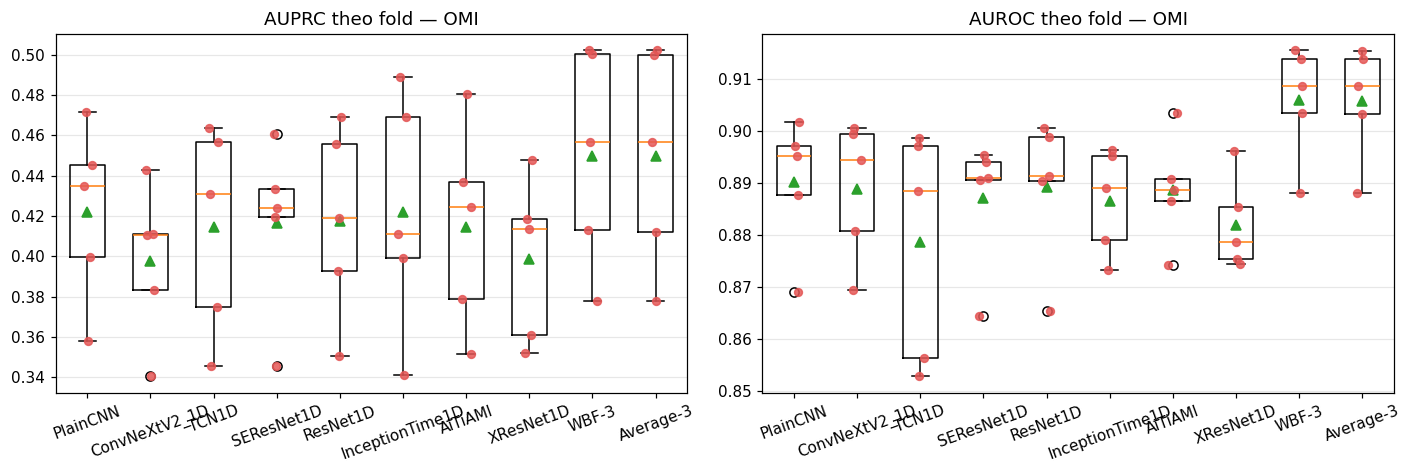

Các hộp chồng lấn nhiều = chênh lệch trung bình không đáng tin; xem lại p-value và CI ở trên trước khi kết luận.


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for j, metric in enumerate(["AUPRC", "AUROC"]):
    data = [FOLD_METRICS.loc[FOLD_METRICS["Model"] == n, metric].to_numpy() for n in ALL_NAMES]
    ax[j].boxplot(data, widths=.55, showmeans=True)   # không dùng labels=: bỏ ở matplotlib 3.9
    ax[j].set_xticks(range(1, len(ALL_NAMES) + 1))
    ax[j].set_xticklabels(ALL_NAMES)
    for i, vals in enumerate(data):
        ax[j].scatter(np.full(len(vals), i + 1) + np.random.uniform(-.08, .08, len(vals)),
                      vals, s=26, color="#E45756", zorder=3, alpha=.85)
    ax[j].set_title(f"{metric} theo fold — {CLASS_NAME}")
    ax[j].grid(alpha=.3, axis="y")
    ax[j].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
print("Các hộp chồng lấn nhiều = chênh lệch trung bình không đáng tin; "
      "xem lại p-value và CI ở trên trước khi kết luận.")

## 17. So khớp ngưỡng: ép mọi model về cùng một điểm vận hành

`Sensitivity` ở bảng so sánh gốc được đo tại ngưỡng Youden's J **riêng của từng model**, nên hai model
có thể "recall khác nhau" chỉ vì ngưỡng của chúng khác nhau, không phải vì model khác nhau. Mục này
ép tất cả về **cùng Specificity = 0,85** (nội suy trên ROC) rồi mới so.

Hai bảng, **khác nguồn dữ liệu, không được đọc gộp**:

- **(a)** toàn bộ mười một model của notebook 06 — nạp lại checkpoint cũ, chỉ chạy inference trên
  đúng tập val 85/15 gốc. Không huấn luyện gì thêm. Bảng này để *sàng* xem có ứng viên thứ tư không.
- **(b)** ba ứng viên + ensemble trên **OOF 5-fold** — chặt hơn hẳn, đây mới là bảng dùng để kết luận.

In [18]:
def find_low_threshold(y_true, y_prob, target_npv=0.99):
    """Ngưỡng THẤP lớn nhất sao cho NPV (của nhóm dưới ngưỡng) vẫn >= target_npv."""
    grid = np.linspace(0.0, 0.5, 501)
    best = 0.0
    for t in grid:
        below = y_prob < t
        if below.sum() == 0:
            continue
        npv = 1 - y_true[below].mean()
        if npv >= target_npv:
            best = t
        else:
            break
    return best


def find_high_threshold(y_true, y_prob, min_group_frac=0.01):
    """Ngưỡng CAO nhỏ nhất sao cho nhóm 'cao' (>= ngưỡng) còn chiếm >= min_group_frac tập."""
    grid = np.linspace(0.99, 0.05, 191)
    n = len(y_true)
    for t in grid:
        above = y_prob >= t
        if above.sum() / n >= min_group_frac:
            ppv = float(y_true[above].mean()) if above.sum() else float("nan")
            return float(t), ppv
    return 0.5, float("nan")


def threshold_at_specificity(y_true, y_prob, target_spec):
    """Ngưỡng cho Specificity = target_spec, nội suy tuyến tính trên đường ROC."""
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    thr = np.clip(thr, 0, 1)                 # thr[0] là +inf theo quy ước của sklearn
    return float(np.interp(1 - target_spec, fpr, thr))


def matched_row(name, y_true, y_prob):
    t_spec = threshold_at_specificity(y_true, y_prob, SPEC_TARGET)
    m = compute_metrics(y_true, y_prob, t_spec)
    t_ro = find_low_threshold(y_true.astype(int), y_prob, RULE_OUT_NPV)
    below = y_prob < t_ro
    return {"Model": name, "AUROC": m["auroc"], "AUPRC": m["auprc"],
            f"Thr@Spec{SPEC_TARGET:.2f}": t_spec, "Sensitivity": m["sensitivity"],
            "Specificity": m["specificity"], "PPV": m["ppv"], "NPV": m["npv"],
            f"Thr rule-out (NPV≥{RULE_OUT_NPV:.0%})": t_ro,
            "% loại được": float(below.mean()),
            "ca dương bị bỏ sót": int(y_true[below].sum())}


MATCH_PCT = ["AUROC", "AUPRC", f"Thr@Spec{SPEC_TARGET:.2f}", "Sensitivity", "Specificity",
             "PPV", "NPV", f"Thr rule-out (NPV≥{RULE_OUT_NPV:.0%})", "% loại được"]

# ---------- (a) inference-only: checkpoint của notebook 06 trên val 85/15 gốc ----------
orig_rows, ORIG_P = [], {}
for _name, _cls in MODELS.items():
    _ck = ORIG_MODEL_DIR / f"{_name.replace('+', '_')}_best.pt"
    if not _ck.exists():
        continue
    try:
        _state = torch.load(_ck, map_location=DEVICE, weights_only=False)
        _m = _cls().to(DEVICE)
        _m.load_state_dict(_state["model"])
    except Exception as e:                    # kiến trúc lệch so với lúc train -> bỏ qua model đó
        print(f"  bỏ qua {_name}: {type(e).__name__} — {e}")
        continue
    _yv, _pv = evaluate(_m, val_loader)
    ORIG_P[_name] = _pv
    orig_rows.append(matched_row(_name, _yv, _pv))
    del _m
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

if orig_rows:
    _wbf_w = {}
    for _n, _p in ORIG_P.items():
        _a = compute_metrics(y[val_idx], _p)["auroc"]
        _wbf_w[_n] = max((0.5 if np.isnan(_a) else _a) - 0.5, 1e-3)
    _s = sum(_wbf_w.values())
    orig_rows.append(matched_row("WBF-ensemble", y[val_idx],
                                 sum(_wbf_w[n] / _s * p for n, p in ORIG_P.items())))
    orig_rows.append(matched_row("Average-ensemble", y[val_idx],
                                 sum(ORIG_P.values()) / len(ORIG_P)))
    orig_df = pd.DataFrame(orig_rows).set_index("Model").sort_values("Sensitivity", ascending=False)
    print("=" * 78)
    print(f"(a) SÀNG — {len(ORIG_P)} model của notebook 06, checkpoint cũ, val 85/15 gốc "
          f"({len(val_idx):,} bản ghi)")
    print("    Nguồn dữ liệu KHÁC bảng (b) — không so trực tiếp hai bảng với nhau.")
    print("=" * 78)
    display(style_df(orig_df, MATCH_PCT))

    _cand_best = orig_df.loc[[c for c in CANDIDATES if c in orig_df.index], "Sensitivity"].max()
    _extra = orig_df[(~orig_df.index.isin(CANDIDATES + ["WBF-ensemble", "Average-ensemble"]))
                     & (orig_df["Sensitivity"] > _cand_best + 0.03)]
    if len(_extra):
        print(f"\n!! ỨNG VIÊN THỨ TƯ: {', '.join(_extra.index)} vượt ứng viên tốt nhất "
              f"({_cand_best:.4f}) hơn 0,03 Sensitivity tại Spec={SPEC_TARGET} — vượt mức nhiễu "
              f"ước lượng. Đề nghị bổ sung vào vòng K-Fold (thêm vào CANDIDATES ở mục 2, chạy lại).")
    else:
        print(f"\nKhông model nào ngoài ba ứng viên vượt quá +0,03 Sensitivity tại "
              f"Spec={SPEC_TARGET} -> giữ nguyên danh sách ứng viên.")
else:
    print("!! Không tìm thấy checkpoint nào trong", ORIG_MODEL_DIR)
    print("   Bảng (a) bị bỏ qua. Muốn có bảng này thì copy checkpoint của notebook 06 vào đó")
    print("   (Colab: thư mục outputs/models trên Drive) rồi chạy lại ô này.")

# ---------- (b) OOF 5-fold, ba ứng viên + ensemble ----------
oof_rows = [matched_row(n, y[VALID], OOF_P[n][0][VALID]) for n in ALL_NAMES]
oof_df = pd.DataFrame(oof_rows).set_index("Model").sort_values("Sensitivity", ascending=False)
print("\n" + "=" * 78)
print(f"(b) KẾT LUẬN — OOF {K_FOLDS} fold, {int(VALID.sum()):,} bản ghi, mọi model tại "
      f"Specificity = {SPEC_TARGET}")
print("=" * 78)
display(style_df(oof_df, MATCH_PCT))

(a) SÀNG — 11 model của notebook 06, checkpoint cũ, val 85/15 gốc (2,704 bản ghi)
    Nguồn dữ liệu KHÁC bảng (b) — không so trực tiếp hai bảng với nhau.


,AUROC,AUPRC,Thr@Spec0.85,Sensitivity,Specificity,PPV,NPV,Thr rule-out (NPV≥99%),% loại được,ca dương bị bỏ sót
Model,,,,,,,,,,
Average-ensemble,0.9292,0.5080,0.3947,0.8736,0.8510,0.2873,0.9899,0.3930,0.8025,21
WBF-ensemble,0.9296,0.5134,0.3994,0.8678,0.8502,0.2849,0.9894,0.3950,0.8010,21
ConvNeXtV2_1D,0.9164,0.4695,0.2426,0.8506,0.8502,0.2808,0.9881,0.1540,0.7718,20
InceptionTime1D,0.9117,0.4961,0.5952,0.8276,0.8498,0.2748,0.9862,0.3820,0.7297,19
PlainCNN,0.9201,0.5219,0.5977,0.8218,0.8502,0.2739,0.9858,0.4810,0.7652,20
AiTiAMI,0.9092,0.4722,0.5745,0.8218,0.8506,0.2745,0.9858,0.2500,0.7241,19
TCN1D,0.9135,0.5160,0.6071,0.8218,0.8502,0.2739,0.9858,0.2960,0.7156,19
ResNet1D,0.9122,0.5134,0.6083,0.8161,0.8502,0.2726,0.9853,0.4290,0.7385,19
SEResNet1D,0.9139,0.4942,0.2988,0.8046,0.8506,0.2703,0.9844,0.1050,0.7293,19



Không model nào ngoài ba ứng viên vượt quá +0,03 Sensitivity tại Spec=0.85 -> giữ nguyên danh sách ứng viên.

(b) KẾT LUẬN — OOF 5 fold, 17,960 bản ghi, mọi model tại Specificity = 0.85


,AUROC,AUPRC,Thr@Spec0.85,Sensitivity,Specificity,PPV,NPV,Thr rule-out (NPV≥99%),% loại được,ca dương bị bỏ sót
Model,,,,,,,,,,
WBF-3,0.9038,0.4311,0.3878,0.8115,0.8501,0.2705,0.9850,0.2080,0.7131,128
Average-3,0.9038,0.4310,0.3875,0.8106,0.8500,0.2700,0.9850,0.2070,0.7129,127
ResNet1D,0.8832,0.3930,0.4560,0.7750,0.8501,0.2614,0.9822,0.1430,0.6607,118
ConvNeXtV2_1D,0.8846,0.3709,0.3482,0.7706,0.8500,0.2603,0.9819,0.0820,0.6773,121
XResNet1D,0.8775,0.3810,0.4770,0.7672,0.8500,0.2594,0.9816,0.0680,0.6190,111
AiTiAMI,0.8854,0.3893,0.5002,0.7637,0.8500,0.2585,0.9813,0.0680,0.6431,115
PlainCNN,0.8770,0.3920,0.4883,0.7593,0.8501,0.2576,0.9810,0.1140,0.6105,108
InceptionTime1D,0.8777,0.3913,0.4253,0.7472,0.8500,0.2544,0.9800,0.0600,0.6242,112
TCN1D,0.8689,0.3884,0.3774,0.7385,0.8500,0.2521,0.9794,0.0190,0.5411,94


## 18. Hiệu chuẩn xác suất bằng cross-fit

Dự án dùng **xác suất liên tục** chứ không phải nhãn nhị phân cứng, nên xác suất phải đọc được như
xác suất thật: trong nhóm được chấm 0,30 thì đúng khoảng 30% là ca dương.

Yêu cầu gốc có một mâu thuẫn: bước 4 cấm hiệu chuẩn trên chính tập dùng để chọn ngưỡng ở bước 5,
nhưng bước 5 lại đòi bootstrap trên *toàn bộ* OOF. Cách gỡ ở đây là **cross-fit**: xác suất của fold
*i* được hiệu chuẩn bằng bộ hiệu chuẩn fit trên OOF của **4 fold còn lại**. Ghép lại thì mọi bản ghi
đều có xác suất "honest" — không bản ghi nào tham gia fit bộ hiệu chuẩn của chính nó — mà vẫn dùng
được hết dữ liệu cho mục 19, thay vì hy sinh một fold (~540 bản ghi, ~35 ca dương, quá ít cho isotonic).

Cross-fit Platt cho WBF-3 ...
Cross-fit Isotonic cho WBF-3 ...

WBF-3 — OOF 17,960 bản ghi


,ECE,Brier,AUROC,AUPRC
Hiệu chuẩn,,,,
thô,0.1253,0.0860,0.9038,0.4311
Platt,0.0033,0.0449,0.9024,0.4257
Isotonic,0.0055,0.0451,0.8988,0.4123


  Platt     ECE 0.1253 -> 0.0033  GIẢM (đạt AC)
  Isotonic  ECE 0.1253 -> 0.0055  GIẢM (đạt AC)
-> Dùng Platt cho phần phân tầng nguy cơ (ECE thấp nhất).


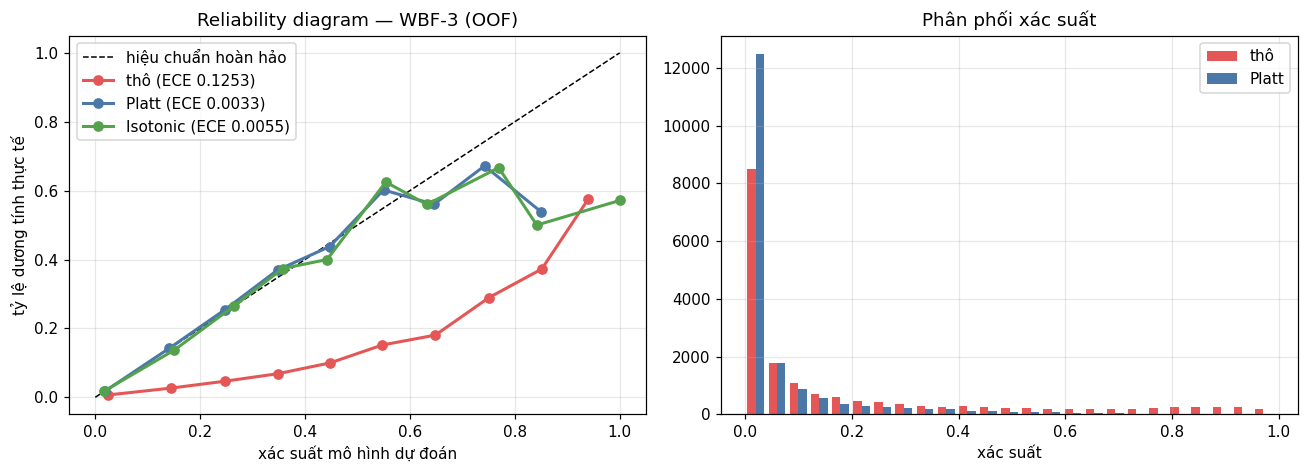


Bảng bin của bản đã hiệu chuẩn:


,bin,n,xác suất TB,tỷ lệ dương thật,lệch
0,"[0.0,0.1)",14807,0.0179,0.0171,-0.0008
1,"[0.1,0.2)",1314,0.1411,0.1423,0.0012
2,"[0.2,0.3)",689,0.2469,0.2540,0.0071
3,"[0.3,0.4)",452,0.3477,0.3695,0.0218
4,"[0.4,0.5)",304,0.4468,0.4375,-0.0093
5,"[0.5,0.6)",201,0.5497,0.6020,0.0523
6,"[0.6,0.7)",116,0.6459,0.5603,-0.0856
7,"[0.7,0.8)",64,0.7423,0.6719,-0.0704
8,"[0.8,0.9)",13,0.8501,0.5385,-0.3117


In [19]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression


def ece_table(y_true, y_prob, n_bins=ECE_BINS):
    """Copy nguyên từ mục 16b của notebook 06."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece, rows = 0.0, []
    for b in range(n_bins):
        m = idx == b
        if not m.sum():
            continue
        conf, acc = float(y_prob[m].mean()), float(y_true[m].mean())
        ece += m.sum() / len(y_prob) * abs(acc - conf)
        rows.append({"bin": f"[{edges[b]:.1f},{edges[b + 1]:.1f})", "n": int(m.sum()),
                     "xác suất TB": conf, "tỷ lệ dương thật": acc, "lệch": acc - conf})
    return float(ece), pd.DataFrame(rows)


def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def crossfit_calibrate(p_raw, method):
    """Fold i được hiệu chuẩn bằng bộ hiệu chuẩn fit trên OOF của các fold KHÁC."""
    out = np.full(len(p_raw), NAN)
    folds_present = [k for k in range(K_FOLDS) if (FOLD_ID[0] == k).any()]
    if len(folds_present) < 2:
        print("  (chỉ có 1 fold — không cross-fit được, fit và áp trên chính nó; chỉ dùng để test pipeline)")
        folds_present = folds_present or [0]
        m = FOLD_ID[0] == folds_present[0]
        fit_mask = apply_mask = m
        pairs = [(fit_mask, apply_mask)]
    else:
        pairs = [((FOLD_ID[0] != k) & VALID, FOLD_ID[0] == k) for k in folds_present]
    for fit_mask, apply_mask in pairs:
        if len(np.unique(y[fit_mask].astype(int))) < 2:
            out[apply_mask] = p_raw[apply_mask]
            continue
        if method == "platt":
            lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
            lr.fit(_logit(p_raw[fit_mask]).reshape(-1, 1), y[fit_mask].astype(int))
            out[apply_mask] = lr.predict_proba(_logit(p_raw[apply_mask]).reshape(-1, 1))[:, 1]
        else:
            iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
            iso.fit(p_raw[fit_mask], y[fit_mask].astype(int))
            out[apply_mask] = iso.predict(p_raw[apply_mask])
    return out


CAL_MODEL = CHAMPION
_p_raw = OOF_P[CAL_MODEL][0]
CAL_P = {"thô": _p_raw}
for _meth, _lbl in [("platt", "Platt"), ("isotonic", "Isotonic")]:
    print(f"Cross-fit {_lbl} cho {CAL_MODEL} ...")
    CAL_P[_lbl] = crossfit_calibrate(_p_raw, _meth)

ECE_ROWS, _tables = [], {}
for _lbl, _p in CAL_P.items():
    _e, _t = ece_table(y[VALID], _p[VALID])
    _tables[_lbl] = _t
    ECE_ROWS.append({"Hiệu chuẩn": _lbl, "ECE": _e,
                     "Brier": float(brier_score_loss(y[VALID].astype(int), _p[VALID])),
                     "AUROC": compute_metrics(y[VALID], _p[VALID])["auroc"],
                     "AUPRC": compute_metrics(y[VALID], _p[VALID])["auprc"]})
ece_df = pd.DataFrame(ECE_ROWS).set_index("Hiệu chuẩn")
print(f"\n{CAL_MODEL} — OOF {int(VALID.sum()):,} bản ghi")
display(style_df(ece_df, ["ECE", "Brier", "AUROC", "AUPRC"]))

_e0 = ece_df.loc["thô", "ECE"]
for _lbl in ["Platt", "Isotonic"]:
    _e1 = ece_df.loc[_lbl, "ECE"]
    print(f"  {_lbl:<9} ECE {_e0:.4f} -> {_e1:.4f}  "
          f"{'GIẢM (đạt AC)' if _e1 < _e0 else 'KHÔNG GIẢM (không đạt AC)'}")
BEST_CAL = min(["Platt", "Isotonic"], key=lambda l: ece_df.loc[l, "ECE"])
print(f"-> Dùng {BEST_CAL} cho phần phân tầng nguy cơ (ECE thấp nhất).")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="hiệu chuẩn hoàn hảo")
for _lbl, _c in zip(CAL_P, ["#E45756", "#4C78A8", "#54A24B"]):
    _t = _tables[_lbl]
    ax[0].plot(_t["xác suất TB"], _t["tỷ lệ dương thật"], marker="o", lw=2, color=_c,
               label=f"{_lbl} (ECE {ece_df.loc[_lbl, 'ECE']:.4f})")
ax[0].set_xlabel("xác suất mô hình dự đoán")
ax[0].set_ylabel("tỷ lệ dương tính thực tế")
ax[0].set_title(f"Reliability diagram — {CAL_MODEL} (OOF)")
ax[0].legend()
ax[0].grid(alpha=.3)
ax[1].hist([CAL_P["thô"][VALID], CAL_P[BEST_CAL][VALID]], bins=25, label=["thô", BEST_CAL],
           color=["#E45756", "#4C78A8"])
ax[1].set_title("Phân phối xác suất")
ax[1].set_xlabel("xác suất")
ax[1].legend()
ax[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

print("\nBảng bin của bản đã hiệu chuẩn:")
display(_tables[BEST_CAL].round(4))

## 19. Phân tầng nguy cơ ba mức kèm khoảng tin cậy

Lặp lại đúng cách phân tầng ở mục 14c/15c của notebook 06 (ngưỡng thấp = mức cao nhất còn giữ
NPV ≥ 99%; ngưỡng cao = mức thấp nhất mà nhóm "cao" vẫn chiếm ≥ 1% tập), nhưng chạy trên xác suất
**đã hiệu chuẩn cross-fit** và kèm **95% CI** thay vì một con số điểm.

Bootstrap lấy mẫu lại **theo bệnh nhân**, không theo bản ghi: 855 bệnh nhân có nhiều hơn một ECG và
các bản ghi của cùng một người tương quan mạnh, nên lấy mẫu theo bản ghi sẽ coi chúng là độc lập và
cho ra khoảng tin cậy hẹp giả tạo. Ngưỡng giữ **cố định** ở giá trị chốt trên toàn bộ OOF — cái được
ước lượng khoảng là NPV/PPV *tại điểm vận hành đã chọn*, đúng như câu hỏi lâm sàng đặt ra.

In [20]:
def patient_groups(mask):
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    return np.split(idx_sorted, np.searchsorted(codes_sorted, np.unique(codes_sorted))[1:])


def tier_report(label, p_all):
    yv, pv = y[VALID].astype(int), p_all[VALID]
    t_low = find_low_threshold(yv, pv, RULE_OUT_NPV)
    t_high, _ = find_high_threshold(yv, pv)
    tier = np.where(pv < t_low, "Thấp", np.where(pv >= t_high, "Cao", "Trung bình"))
    rows = []
    for lvl in ["Thấp", "Trung bình", "Cao"]:
        m = tier == lvl
        rows.append({"Mức": lvl, "n": int(m.sum()), "tỷ lệ n": m.mean(),
                     "dương": int(yv[m].sum()), "tỷ lệ dương trong nhóm": _div(int(yv[m].sum()), int(m.sum()))})
    print("=" * 78)
    print(f"{label}  |  ngưỡng thấp {t_low:.3f}  |  ngưỡng cao {t_high:.3f}")
    print("=" * 78)
    display(pd.DataFrame(rows).set_index("Mức").style.format(
        {"tỷ lệ n": "{:.2%}", "tỷ lệ dương trong nhóm": "{:.2%}", "n": "{:,d}", "dương": "{:,d}"}))

    groups = patient_groups(VALID)
    pos_in = {i: j for j, i in enumerate(np.where(VALID)[0])}
    rng = np.random.default_rng(SEED)
    npv_b, ppv_b, frac_b = [], [], []
    for _ in range(N_BOOTSTRAP):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        loc = np.array([pos_in[i] for i in sel])
        ys, ps = yv[loc], pv[loc]
        low, high = ps < t_low, ps >= t_high
        npv_b.append(1 - ys[low].mean() if low.any() else NAN)
        ppv_b.append(ys[high].mean() if high.any() else NAN)
        frac_b.append(low.mean())
    ci = lambda a: np.nanpercentile(np.asarray(a, dtype=float), [2.5, 97.5])
    npv_pt = 1 - yv[pv < t_low].mean() if (pv < t_low).any() else NAN
    ppv_pt = yv[pv >= t_high].mean() if (pv >= t_high).any() else NAN
    n_lo, h_lo = ci(npv_b), ci(ppv_b)
    f_lo = ci(frac_b)
    print(f"\nBootstrap {N_BOOTSTRAP:,} lần, lấy mẫu lại theo {len(groups):,} bệnh nhân:")
    display(pd.DataFrame([
        {"Chỉ số": f"NPV nhóm THẤP (rule-out)", "Điểm": npv_pt,
         "95% CI": f"[{n_lo[0]:.4f}, {n_lo[1]:.4f}]"},
        {"Chỉ số": f"PPV nhóm CAO (rule-in)", "Điểm": ppv_pt,
         "95% CI": f"[{h_lo[0]:.4f}, {h_lo[1]:.4f}]"},
        {"Chỉ số": "% bệnh nhân loại được ở nhóm THẤP", "Điểm": float((pv < t_low).mean()),
         "95% CI": f"[{f_lo[0]:.4f}, {f_lo[1]:.4f}]"},
    ]).set_index("Chỉ số").style.format({"Điểm": "{:.4f}"}))
    return {"t_low": t_low, "t_high": t_high, "npv_ci": n_lo, "ppv_ci": h_lo}


TIER_RAW = tier_report(f"{CAL_MODEL} — xác suất THÔ (OOF)", CAL_P["thô"])
print()
TIER_CAL = tier_report(f"{CAL_MODEL} — sau hiệu chuẩn {BEST_CAL} (cross-fit)", CAL_P[BEST_CAL])

WBF-3 — xác suất THÔ (OOF)  |  ngưỡng thấp 0.208  |  ngưỡng cao 0.950


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,"12,808",71.31%,128,1.00%
Trung bình,"4,965",27.64%,909,18.31%
Cao,187,1.04%,114,60.96%



Bootstrap 1,000 lần, lấy mẫu lại theo 17,018 bệnh nhân:


,Điểm,95% CI
Chỉ số,,
NPV nhóm THẤP (rule-out),0.9900,"[0.9883, 0.9917]"
PPV nhóm CAO (rule-in),0.6096,"[0.5377, 0.6843]"
% bệnh nhân loại được ở nhóm THẤP,0.7131,"[0.7065, 0.7198]"



WBF-3 — sau hiệu chuẩn Platt (cross-fit)  |  ngưỡng thấp 0.044  |  ngưỡng cao 0.609


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,"12,746",70.97%,127,1.00%
Trung bình,"5,031",28.01%,915,18.19%
Cao,183,1.02%,109,59.56%



Bootstrap 1,000 lần, lấy mẫu lại theo 17,018 bệnh nhân:


,Điểm,95% CI
Chỉ số,,
NPV nhóm THẤP (rule-out),0.9900,"[0.9883, 0.9918]"
PPV nhóm CAO (rule-in),0.5956,"[0.5242, 0.6723]"
% bệnh nhân loại được ở nhóm THẤP,0.7097,"[0.7031, 0.7165]"


## 20. (Tuỳ chọn) Sweep hyperparameter nhẹ

Mặc định **tắt** (`RUN_SWEEP = False` ở mục 2) vì tốn thêm nhiều giờ GPU. Bật lên thì chạy hai giai đoạn:

1. **Thô** — learning rate ∈ {5e-4, 1e-3, 2e-3}, **chỉ fold 0**, cho từng ứng viên.
2. **Tinh** — với LR tốt nhất của từng model: dropout ∈ {0.2, 0.3, 0.4} × loss ∈ {pos_weight, focal γ=2},
   vẫn ở fold 0; tổ hợp thắng của mỗi model mới chạy đủ 5 fold.

`PlainCNN` không có tham số `dropout` trong `__init__` nên phần dropout tự động bỏ qua với model này —
sweep của nó chỉ gồm learning rate và loss.

Kết quả sweep **không** dùng lại được số liệu CV ở mục 14: những con số đó chạy ở hyperparameter mặc
định, không áp cho tổ hợp mới.

In [21]:
import inspect
from functools import partial


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma, self.alpha = gamma, alpha

    def forward(self, logits, target):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, target, reduction="none")
        p_t = torch.exp(-bce)
        a_t = self.alpha * target + (1 - self.alpha) * (1 - target)
        return (a_t * (1 - p_t) ** self.gamma * bce).mean()


def train_variant(name, cls, rep, k, lr, loss_kind, pos_weight, tr_loader, va_loader, tag):
    """Như train_fold nhưng cho phép đổi LR / dropout / loss. Checkpoint riêng theo tag."""
    ckpt = MODEL_DIR / f"sweep_{tag.replace('+', '_').replace('=', '').replace(' ', '_')}.pt"
    fp = dict(CV_FP, model=name, rep=rep, fold=k, tag=tag)
    fp.pop("models"), fp.pop("n_folds_run")
    if ckpt.exists():
        ck = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            print(f"  [{tag}] có checkpoint khớp -> bỏ qua (AUPRC {ck['best']:.4f})")
            return ck["best"]

    torch.manual_seed(SEED + rep)
    model = cls().to(DEVICE)
    criterion = (FocalLoss() if loss_kind == "focal" else
                 nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE)))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = ReduceLROnPlateau(opt, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    best, bad = -np.inf, 0
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()
        m = compute_metrics(*evaluate(model, va_loader))
        sched.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, bad = float(m["auprc"]), 0
            torch.save({"model": model.state_dict(), "fp": fp, "best": best}, ckpt)
        else:
            bad += 1
            if bad >= EARLY_STOP_PATIENCE:
                break
    del model
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()
    print(f"  [{tag}] best AUPRC {best:.4f}")
    return best


if not RUN_SWEEP:
    print("RUN_SWEEP = False -> bỏ qua sweep. Đặt True ở mục 2 để chạy (tốn nhiều giờ GPU).")
else:
    _tr0, _va0 = FOLDS[(0, 0)]
    _mean0, _std0 = norm_stats(_tr0)
    _trl, _val = make_loaders(_tr0, _va0, _mean0, _std0)
    _npos0 = int(y[_tr0].sum())
    _pw0 = float((len(_tr0) - _npos0) / max(_npos0, 1))

    sweep_rows, BEST_HP = [], {}
    for _name in CANDIDATES:
        _cls = MODELS[_name]
        # --- giai đoạn thô: learning rate, chỉ fold 0 ---
        _lr_scores = {}
        for _lr in [5e-4, 1e-3, 2e-3]:
            _tag = f"{_name} lr={_lr}"
            _lr_scores[_lr] = train_variant(_name, _cls, 0, 0, _lr, "bce", _pw0, _trl, _val, _tag)
            sweep_rows.append({"Model": _name, "Giai đoạn": "thô", "LR": _lr, "dropout": None,
                               "loss": "bce", "AUPRC fold0": _lr_scores[_lr]})
        _best_lr = max(_lr_scores, key=_lr_scores.get)

        # --- giai đoạn tinh: dropout × loss, vẫn fold 0 ---
        _has_dropout = "dropout" in inspect.signature(_cls.__init__).parameters
        _drops = [0.2, 0.3, 0.4] if _has_dropout else [None]
        if not _has_dropout:
            print(f"  ({_name} không nhận tham số dropout -> chỉ sweep loss)")
        _fine = {}
        for _dp in _drops:
            for _loss in ["bce", "focal"]:
                _mk = partial(_cls, dropout=_dp) if _dp is not None else _cls
                _tag = f"{_name} lr={_best_lr} dp={_dp} {_loss}"
                _sc = train_variant(_name, _mk, 0, 0, _best_lr, _loss, _pw0, _trl, _val, _tag)
                _fine[(_dp, _loss)] = _sc
                sweep_rows.append({"Model": _name, "Giai đoạn": "tinh", "LR": _best_lr,
                                   "dropout": _dp, "loss": _loss, "AUPRC fold0": _sc})
        _bd, _bl = max(_fine, key=_fine.get)
        BEST_HP[_name] = {"lr": _best_lr, "dropout": _bd, "loss": _bl}
        print(f"-> {_name}: lr={_best_lr}, dropout={_bd}, loss={_bl}")

    display(style_df(pd.DataFrame(sweep_rows).set_index(["Model", "Giai đoạn"]), ["AUPRC fold0"]))

    # --- tổ hợp thắng của từng model chạy đủ K fold ---
    full_rows = []
    for _name, _hp in BEST_HP.items():
        _cls = MODELS[_name]
        _mk = partial(_cls, dropout=_hp["dropout"]) if _hp["dropout"] is not None else _cls
        for _k in range(N_FOLDS_RUN):
            _tr, _va = FOLDS[(0, _k)]
            _m, _s = norm_stats(_tr)
            _tl, _vl = make_loaders(_tr, _va, _m, _s)
            _np_ = int(y[_tr].sum())
            _pw = float((len(_tr) - _np_) / max(_np_, 1))
            _tag = f"{_name} TUNED f{_k}"
            full_rows.append({"Model": f"{_name} (tuned)", "fold": _k,
                              "AUPRC": train_variant(_name, _mk, 0, _k, _hp["lr"], _hp["loss"],
                                                     _pw, _tl, _vl, _tag)})
    tuned_df = pd.DataFrame(full_rows)
    display(style_df(tuned_df.groupby("Model")["AUPRC"].agg(["mean", "std"]), ["mean"]))
    print("So với mục 15 (hyperparameter mặc định) để biết tuning có đáng hay không.")

RUN_SWEEP = False -> bỏ qua sweep. Đặt True ở mục 2 để chạy (tốn nhiều giờ GPU).


## 21. Lưu ý khi kết luận

- **8 ứng viên (mở rộng theo ngưỡng ±0,015 AUROC), không phải mười một.** Ba kiến trúc còn lại
  (`CNN+BiLSTM`, `PaperBaselineCNN`, `Transformer1D`) chỉ xuất hiện ở bảng sàng 17(a) với checkpoint
  cũ trên lần chia 85/15 gốc. Chúng **chưa** qua K-Fold, nên không có khoảng tin cậy và không được
  xếp hạng chung với các ứng viên đã qua K-Fold.
- **Hai bảng ở mục 17 khác nguồn dữ liệu.** (a) là một lần chia 85/15; (b) là OOF 5 fold. Con số
  không so trực tiếp được với nhau.
- **Wilcoxon ở K = 5 không thể cho p hai phía < 0,05** (xem mục 16). Đọc kết luận dựa vào bootstrap
  CI của ΔAUPRC là chính.
- **Ngưỡng ở mục 19 chốt trên OOF, chưa phải trên dữ liệu độc lập.** Tập test ẩn 10% vẫn chưa được
  chạm tới ở bất kỳ bước nào của notebook này. Trước khi dùng lâm sàng, ngưỡng phải được xác nhận lại
  trên một tập độc lập.
- **Hiệu chuẩn phụ thuộc tỷ lệ mắc.** Tỷ lệ dương ở đây (6,43% OMI) là của quần thể đã được chỉ định
  chụp mạch, cao hơn nhiều so với quần thể cấp cứu chung. Đưa sang nơi khác thì phải hiệu chuẩn lại.
- **Chưa làm:** kiểm tra ngoài phân phối trên Georgia / Chapman-Shaoxing (không có dữ liệu CinC2021
  trong `datasets/`) và phân tích lỗi false-negative kèm Grad-CAM — hai việc này để notebook riêng.

## 22. Kiểm chứng phân nhóm NSTEMI (5-fold + bootstrap)

Notebook `06` mục 15b đo hiệu năng trên phân nhóm NSTEMI (ca OMI mà tiêu chí ST chênh lên bỏ sót)
bằng **một lần chia 85/15 duy nhất** — n = 176, chỉ 49 ca dương — và tự cảnh báo con số đó
(AUROC ~0,71) có thể là nhiễu, cần "bootstrap khoảng tin cậy hoặc gộp nhiều seed" mới kết luận
được. Mục này làm đúng việc đó, **tái dùng OOF predictions đã có sẵn ở mục 14** (không train lại):

1. Lọc `is_nstemi` trên đúng các bản ghi đã có dự đoán OOF (`VALID`).
2. Với mỗi (model, fold), tính lại AUROC/AUPRC/Sensitivity/Specificity/PPV/NPV/F1 **chỉ trên phần
   NSTEMI của fold đó**, giữ nguyên ngưỡng Youden's J đã chốt cho toàn bộ fold ở mục 15 (đúng
   nguyên tắc notebook 06: một ngưỡng duy nhất khi triển khai thật, không biết trước bệnh nhân
   thuộc phân nhóm nào).
3. Fold nào có dưới `MIN_POS_SUBGROUP` ca dương trong phân nhóm thì loại khỏi trung bình — metric
   trên quá ít ca dương chỉ là nhiễu, in ra vẫn gây hiểu lầm.
4. Kiểm định ghép cặp (Wilcoxon một phía + bootstrap CI của ΔAUPRC, lấy mẫu lại theo bệnh nhân,
   **chỉ trong phân nhóm NSTEMI**) giữa hai model đầu bảng.
5. Bootstrap CI 95% cho chính AUROC/AUPRC của model tốt nhất trên phân nhóm.

⚠️ Cỡ mẫu phân nhóm mỗi fold nhỏ hơn nhiều so với toàn tập (toàn phân nhóm NSTEMI ~1.235 bản ghi
chia 5 fold ~247/fold, ~85 ca dương/fold) — vẫn có thể ít hơn ngưỡng an toàn thống kê. Đọc kết quả
kèm cột `n_pos` của từng fold trước khi tin bất kỳ con số trung bình nào.

In [22]:
MIN_POS_SUBGROUP_NSTEMI = 5

is_nstemi_all = (df["NSTEMI"].astype(int).to_numpy() == 1) & VALID
print(f"Toàn bộ phân nhóm NSTEMI có OOF: n={int(is_nstemi_all.sum()):,} | "
      f"OMI={int(y[is_nstemi_all].sum()):,} ({y[is_nstemi_all].mean():.1%} dương)")

sub_rows = []
for name in ALL_NAMES:
    for rep in range(N_REPEATS):
        for k in range(N_FOLDS_RUN):
            m_fold = FOLD_ID[rep] == k
            m_sub = m_fold & is_nstemi_all
            n_sub, n_pos_sub = int(m_sub.sum()), int(y[m_sub].sum())
            if n_pos_sub < MIN_POS_SUBGROUP_NSTEMI or n_pos_sub == n_sub:
                sub_rows.append({"Model": name, "lặp": rep, "fold": k, "n": n_sub,
                                  "n_pos": n_pos_sub, "dùng được": False,
                                  "AUROC": np.nan, "AUPRC": np.nan, "Sensitivity": np.nan,
                                  "Specificity": np.nan, "PPV": np.nan, "NPV": np.nan, "F1": np.nan})
                continue
            # Ngưỡng: giữ nguyên ngưỡng Youden's J đã chốt cho TOÀN BỘ fold ở mục 15 —
            # không tính lại riêng cho phân nhóm (đúng cách triển khai thật).
            thr_fold = youden_threshold(y[m_fold], OOF_P[name][rep, m_fold])
            met = compute_metrics(y[m_sub], OOF_P[name][rep, m_sub], thr_fold)
            sub_rows.append({"Model": name, "lặp": rep, "fold": k, "n": n_sub, "n_pos": n_pos_sub,
                              "dùng được": True, "AUROC": met["auroc"], "AUPRC": met["auprc"],
                              "Sensitivity": met["sensitivity"], "Specificity": met["specificity"],
                              "PPV": met["ppv"], "NPV": met["npv"], "F1": met["f1"]})

SUB_FOLD_METRICS = pd.DataFrame(sub_rows)
print("\n" + "=" * 78)
print("PHÂN NHÓM NSTEMI — từng fold (ngưỡng giữ nguyên từ mục 15)")
print("=" * 78)
display(SUB_FOLD_METRICS.set_index(["Model", "lặp", "fold"]))

n_bad = (~SUB_FOLD_METRICS["dùng được"]).sum()
if n_bad:
    print(f"\n!! {n_bad} dòng bị loại vì fold đó có dưới {MIN_POS_SUBGROUP_NSTEMI} ca dương trong "
          f"phân nhóm — không đưa vào trung bình.")

usable = SUB_FOLD_METRICS[SUB_FOLD_METRICS["dùng được"]]
sub_agg = usable.groupby("Model")[["AUROC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV", "F1"]]
sub_summary = sub_agg.agg(["mean", "std", "count"])
sub_summary.columns = [f"{c}_{s}" for c, s in sub_summary.columns]
sub_summary = sub_summary.sort_values("AUPRC_mean", ascending=False)
print("\nTrung bình ± độ lệch chuẩn qua các fold DÙNG ĐƯỢC (phân nhóm NSTEMI):")
display(sub_summary[[c for c in sub_summary.columns if not c.endswith("_std")]].round(4))
display(sub_summary[[c for c in sub_summary.columns if c.endswith("_std")]].round(4))

SUB_CHAMPION = sub_summary.index[0]
SUB_CHALLENGER = sub_summary.index[1] if len(sub_summary) > 1 else None
n_folds_used = int(sub_summary.loc[SUB_CHAMPION, "AUPRC_count"])
print(f"\n-> Hạng 1 trên phân nhóm NSTEMI: {SUB_CHAMPION} "
      f"(AUPRC {sub_summary.loc[SUB_CHAMPION, 'AUPRC_mean']:.4f} "
      f"± {sub_summary.loc[SUB_CHAMPION, 'AUPRC_std']:.4f}, dựa trên {n_folds_used} fold dùng được)")
if n_folds_used < K_FOLDS:
    print(f"   !! Chỉ {n_folds_used}/{K_FOLDS} fold có đủ ca dương trong phân nhóm — "
          f"KHÔNG đủ để coi con số trung bình này là ổn định.")


Toàn bộ phân nhóm NSTEMI có OOF: n=1,235 | OMI=423 (34.3% dương)

PHÂN NHÓM NSTEMI — từng fold (ngưỡng giữ nguyên từ mục 15)


n  n_pos  dùng được     AUROC     AUPRC  Sensitivity  Specificity       PPV       NPV        F1
Model           lặp fold                                                                                                   
PlainCNN        0   0     260     79       True  0.678509  0.518276     0.607595     0.635359  0.421053  0.787671  0.497409
                    1     241     76       True  0.618939  0.408807     0.671053     0.569697  0.418033  0.789916  0.515152
                    2     218     79       True  0.658456  0.516650     0.645570     0.539568  0.443478  0.728155  0.525773
                    3     248     87       True  0.581995  0.401618     0.678161     0.472050  0.409722  0.730769  0.510823
                    4     268    102       True  0.685477  0.551806     0.715686     0.626506  0.540741  0.781955  0.616034
ConvNeXtV2_1D   0   0     260     79       True  0.698196  0.480621     0.772152     0.552486  0.429577  0.847458  0.552036
                    1     241     76       True  0.625040  0.461852     0.657895     0.545455  0.400000  0.775862  0.497512
                    2     218     79       True  0.654995  0.514177     0.696203     0.575540  0.482456  0.769231  0.569948
                    3     248     87       True  0.584850  0.393914     0.712644     0.428571  0.402597  0.734043  0.514523
                    4     268    102       True  0.675171  0.584745     0.617647     0.656627  0.525000  0.736486  0.567568
TCN1D           0   0     260     79       True  0.708406  0.527597     0.645570     0.668508  0.459459  0.812081  0.536842
                    1     241     76       True  0.609769  0.441153     0.697368     0.472727  0.378571  0.772277  0.490741
                    2     218     79       True  0.642200  0.496387     0.683544     0.539568  0.457627  0.750000  0.548223
                    3     248     87       True  0.547548  0.392293     0.563218     0.484472  0.371212  0.672414  0.447489
                    4     268    102       True  0.644253  0.523952     0.656863     0.608434  0.507576  0.742647  0.572650
SEResNet1D      0   0     260     79       True  0.700538  0.511394     0.683544     0.635359  0.450000  0.821429  0.542714
                    1     241     76       True  0.613955  0.445922     0.578947     0.587879  0.392857  0.751938  0.468085
                    2     218     79       True  0.680949  0.524690     0.797468     0.532374  0.492188  0.822222  0.608696
                    3     248     87       True  0.602734  0.437377     0.666667     0.521739  0.429630  0.743363  0.522523
                    4     268    102       True  0.676707  0.557166     0.754902     0.512048  0.487342  0.772727  0.592308
ResNet1D        0   0     260     79       True  0.669068  0.479528     0.746835     0.530387  0.409722  0.827586  0.529148
                    1     241     76       True  0.633612  0.438443     0.776316     0.412121  0.378205  0.800000  0.508621
                    2     218     79       True  0.669292  0.506621     0.822785     0.438849  0.454545  0.813333  0.585586
                    3     248     87       True  0.576283  0.406244     0.655172     0.534161  0.431818  0.741379  0.520548
                    4     268    102       True  0.670860  0.535584     0.598039     0.722892  0.570093  0.745342  0.583732
InceptionTime1D 0   0     260     79       True  0.699350  0.539496     0.683544     0.624309  0.442623  0.818841  0.537313
                    1     241     76       True  0.633174  0.455946     0.684211     0.521212  0.396947  0.781818  0.502415
                    2     218     79       True  0.637374  0.477822     0.759494     0.496403  0.461538  0.784091  0.574163
                    3     248     87       True  0.586278  0.406597     0.620690     0.509317  0.406015  0.713043  0.490909
                    4     268    102       True  0.675496  0.540700     0.705882     0.560241  0.496552  0.756098  0.582996
AiTiAMI         0   0     260     79       True  0.697531  0


Trung bình ± độ lệch chuẩn qua các fold DÙNG ĐƯỢC (phân nhóm NSTEMI):


,AUROC_mean,AUROC_count,AUPRC_mean,AUPRC_count,Sensitivity_mean,Sensitivity_count,Specificity_mean,Specificity_count,PPV_mean,PPV_count,NPV_mean,NPV_count,F1_mean,F1_count
Model,,,,,,,,,,,,,,
SEResNet1D,0.6550,5,0.4953,5,0.6963,5,0.5579,5,0.4504,5,0.7823,5,0.5469,5
WBF-3,0.6613,5,0.4919,5,0.7238,5,0.5497,5,0.4568,5,0.7928,5,0.5592,5
Average-3,0.6612,5,0.4917,5,0.6848,5,0.5914,5,0.4658,5,0.7837,5,0.5543,5
AiTiAMI,0.6475,5,0.4897,5,0.6768,5,0.5707,5,0.4529,5,0.7717,5,0.5415,5
ConvNeXtV2_1D,0.6477,5,0.4871,5,0.6913,5,0.5517,5,0.4479,5,0.7726,5,0.5403,5
InceptionTime1D,0.6463,5,0.4841,5,0.6908,5,0.5423,5,0.4407,5,0.7708,5,0.5376,5
PlainCNN,0.6447,5,0.4794,5,0.6636,5,0.5686,5,0.4466,5,0.7637,5,0.5330,5
TCN1D,0.6304,5,0.4763,5,0.6493,5,0.5547,5,0.4349,5,0.7499,5,0.5192,5
ResNet1D,0.6438,5,0.4733,5,0.7198,5,0.5277,5,0.4489,5,0.7855,5,0.5455,5


,AUROC_std,AUPRC_std,Sensitivity_std,Specificity_std,PPV_std,NPV_std,F1_std
Model,,,,,,,
SEResNet1D,0.0437,0.0518,0.0844,0.0523,0.0414,0.0376,0.0564
WBF-3,0.0487,0.0613,0.0480,0.0577,0.0459,0.0327,0.0433
Average-3,0.0488,0.0614,0.0654,0.0415,0.0464,0.0340,0.0530
AiTiAMI,0.0501,0.0587,0.0537,0.0674,0.0547,0.0369,0.0500
ConvNeXtV2_1D,0.0442,0.0701,0.0582,0.0818,0.0544,0.0459,0.0326
InceptionTime1D,0.0434,0.0573,0.0499,0.0517,0.0408,0.0392,0.0413
PlainCNN,0.0436,0.0692,0.0401,0.0670,0.0541,0.0314,0.0475
TCN1D,0.0585,0.0583,0.0524,0.0832,0.0584,0.0510,0.0499
ResNet1D,0.0409,0.0518,0.0916,0.1219,0.0734,0.0397,0.0365



-> Hạng 1 trên phân nhóm NSTEMI: SEResNet1D (AUPRC 0.4953 ± 0.0518, dựa trên 5 fold dùng được)


In [23]:
# ---- Kiểm định ghép cặp + bootstrap CI, GIỚI HẠN TRONG PHÂN NHÓM NSTEMI ----

def cluster_bootstrap_delta_subgroup(name_a, name_b, mask, n_boot=N_BOOTSTRAP, seed=SEED):
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    starts = np.searchsorted(codes_sorted, np.unique(codes_sorted))
    groups = np.split(idx_sorted, starts[1:])
    rng = np.random.default_rng(seed)
    pa, pb = OOF_P[name_a][0], OOF_P[name_b][0]
    out = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        ys = y[sel]
        if len(np.unique(ys.astype(int))) < 2:
            continue
        out.append(average_precision_score(ys, pa[sel]) - average_precision_score(ys, pb[sel]))
    return np.asarray(out)


def cluster_bootstrap_point_subgroup(name, mask, metric_fn, n_boot=N_BOOTSTRAP, seed=SEED):
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    starts = np.searchsorted(codes_sorted, np.unique(codes_sorted))
    groups = np.split(idx_sorted, starts[1:])
    rng = np.random.default_rng(seed)
    p = OOF_P[name][0]
    out = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        ys = y[sel]
        if len(np.unique(ys.astype(int))) < 2:
            continue
        out.append(metric_fn(ys, p[sel]))
    return np.asarray(out)


print("=" * 78)
print(f"BOOTSTRAP CI (theo bệnh nhân, {N_BOOTSTRAP} lần) — {SUB_CHAMPION} trên phân nhóm NSTEMI")
print("=" * 78)
boot_auroc = cluster_bootstrap_point_subgroup(SUB_CHAMPION, is_nstemi_all, roc_auc_score)
boot_auprc = cluster_bootstrap_point_subgroup(SUB_CHAMPION, is_nstemi_all, average_precision_score)
for label, boot in [("AUROC", boot_auroc), ("AUPRC", boot_auprc)]:
    if len(boot):
        lo, hi = np.percentile(boot, [2.5, 97.5])
        print(f"{label}: điểm {boot.mean():.4f}  95% CI [{lo:.4f}, {hi:.4f}]  (n hợp lệ = {len(boot)}/{N_BOOTSTRAP})")
    else:
        print(f"{label}: không đủ dữ liệu để bootstrap.")

if SUB_CHALLENGER is not None:
    print("\n" + "=" * 78)
    print(f"KIỂM ĐỊNH GHÉP CẶP — {SUB_CHAMPION} vs {SUB_CHALLENGER} (chỉ trên phân nhóm NSTEMI, {n_folds_used} fold)")
    print("=" * 78)
    piv = usable.pivot_table(index=["lặp", "fold"], columns="Model", values="AUPRC")
    common_idx = piv[[SUB_CHAMPION, SUB_CHALLENGER]].dropna().index
    a = piv.loc[common_idx, SUB_CHAMPION].to_numpy()
    b = piv.loc[common_idx, SUB_CHALLENGER].to_numpy()
    d = a - b
    n_pair = len(d)
    display(pd.DataFrame({SUB_CHAMPION: a, SUB_CHALLENGER: b, "Δ": d}, index=common_idx).round(4))
    print(f"{SUB_CHAMPION} thắng {int((d > 0).sum())}/{n_pair} fold | Δ trung bình {d.mean():+.4f}")

    if n_pair < 2 or np.allclose(d, 0):
        print("Không đủ fold ghép cặp để kiểm định thống kê.")
    else:
        p_one = wilcoxon(a, b, alternative="greater").pvalue if not np.all(d <= 0) else 1.0
        p_two = wilcoxon(a, b, alternative="two-sided").pvalue
        p_min_two = 2 / (2 ** n_pair)
        print(f"Wilcoxon một phía  p = {p_one:.4f}")
        print(f"Wilcoxon hai phía  p = {p_two:.4f}   (p nhỏ nhất có thể ở n={n_pair}: {p_min_two:.5f}"
              f"{' — KHÔNG THỂ < 0,05' if p_min_two > 0.05 else ''})")

        delta_boot = cluster_bootstrap_delta_subgroup(SUB_CHAMPION, SUB_CHALLENGER, is_nstemi_all)
        if len(delta_boot):
            lo, hi = np.percentile(delta_boot, [2.5, 97.5])
            sig = "CÓ Ý NGHĨA (CI không chứa 0)" if lo > 0 or hi < 0 else "KHÔNG PHÂN BIỆT ĐƯỢC (CI chứa 0)"
            print(f"Bootstrap ΔAUPRC (theo bệnh nhân, {len(delta_boot)} lần): "
                  f"{delta_boot.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  -> {sig}")
        else:
            print("Không đủ dữ liệu để bootstrap Δ.")
else:
    print("\nChỉ có một model dùng được trên phân nhóm này — không có gì để so sánh ghép cặp.")

print("\n" + "=" * 78)
print("KẾT LUẬN MỤC 22")
print("=" * 78)
print(f"So với con số một-lần-chia của notebook 06 (AUROC ~0,71, n=176, 49 ca dương), kết quả")
print(f"5-fold ở đây dựa trên {n_folds_used}/{K_FOLDS} fold dùng được, mỗi fold ~{int(usable['n'].mean())} bản ghi")
print(f"/ ~{int(usable['n_pos'].mean())} ca dương. Đọc khoảng CI ở trên trước khi trích dẫn bất kỳ")
print(f"con số điểm nào làm kết luận cuối cùng về giá trị lâm sàng ở phân nhóm NSTEMI.")


BOOTSTRAP CI (theo bệnh nhân, 1000 lần) — SEResNet1D trên phân nhóm NSTEMI
AUROC: điểm 0.6382  95% CI [0.6057, 0.6706]  (n hợp lệ = 1000/1000)
AUPRC: điểm 0.4709  95% CI [0.4207, 0.5236]  (n hợp lệ = 1000/1000)

KIỂM ĐỊNH GHÉP CẶP — SEResNet1D vs WBF-3 (chỉ trên phân nhóm NSTEMI, 5 fold)


SEResNet1D   WBF-3       Δ
lặp fold                            
0   0         0.5114  0.5331 -0.0217
    1         0.4459  0.4457  0.0003
    2         0.5247  0.5050  0.0197
    3         0.4374  0.4138  0.0235
    4         0.5572  0.5621 -0.0050

SEResNet1D thắng 3/5 fold | Δ trung bình +0.0034
Wilcoxon một phía  p = 0.4062
Wilcoxon hai phía  p = 0.8125   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Bootstrap ΔAUPRC (theo bệnh nhân, 1000 lần): -0.0074  95% CI [-0.0294, +0.0165]  -> KHÔNG PHÂN BIỆT ĐƯỢC (CI chứa 0)

KẾT LUẬN MỤC 22
So với con số một-lần-chia của notebook 06 (AUROC ~0,71, n=176, 49 ca dương), kết quả
5-fold ở đây dựa trên 5/5 fold dùng được, mỗi fold ~247 bản ghi
/ ~84 ca dương. Đọc khoảng CI ở trên trước khi trích dẫn bất kỳ
con số điểm nào làm kết luận cuối cùng về giá trị lâm sàng ở phân nhóm NSTEMI.
